# DATA QUALITY

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import subprocess
import sys
warnings.filterwarnings('ignore')

import scipy.stats as stats
from scipy.stats import levene, shapiro, kstest, normaltest, chi2_contingency
from scipy.spatial.distance import pdist, squareform, mahalanobis

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
except:
    print("LightGBM not installed. Install with: pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    print("CatBoost not installed. Trying runtime install...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "-q"])
        from catboost import CatBoostClassifier
        CATBOOST_AVAILABLE = True
        print("✓ CatBoost installed successfully")
    except Exception as catboost_install_error:
        CATBOOST_AVAILABLE = False
        CatBoostClassifier = None
        print(f"CatBoost unavailable after install attempt: {catboost_install_error}")

try:
    import shap
except:
    print("SHAP not installed. Install with: pip install shap")

try:
    import optuna
    from optuna import Trial
except:
    print("Optuna not installed. Install with: pip install optuna")

try:
    import h2o
    from h2o.automl import H2OAutoML
except:
    print("H2O not installed. Install with: pip install h2o")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


---
# 1. UČITAVANJE I OSNOVNA ANALIZA PODATAKA

In [3]:
path = "~/DATAPREPROCESSING/BankChurners.csv"
data = pd.read_csv(path)

In [4]:
data = data.drop('Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', axis = 1)
data = data.drop('Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',axis = 1)
#Uradjeno po upustvu autora dataseta

print(f"\nFinal dataset shape: {data.shape}")
data.head()


Final dataset shape: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [5]:
print("DATASET INFORMATION")
print("="*80)
data.info()

print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected ✓")

print("\n" + "="*80)
print("DUPLICATE ROWS")
print("="*80)
duplicates = data.drop('CLIENTNUM', axis=1).duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print("No duplicates ✓" if duplicates == 0 else f"Warning: {duplicates} duplicates found")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null 

---
# 2. TIPOVI ATRIBUTA I PROFILISANJE



In [6]:
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

if 'CLIENTNUM' in numerical_cols:
    numerical_cols.remove('CLIENTNUM')

print("="*80)
print("NUMERICAL ATTRIBUTES ({}):".format(len(numerical_cols)))
print("="*80)
for i, col in enumerate(numerical_cols, 1):
    print(f"{i:2d}. {col}")

print("\n" + "="*80)
print("CATEGORICAL ATTRIBUTES ({}):".format(len(categorical_cols)))
print("="*80)
for i, col in enumerate(categorical_cols, 1):
    unique_count = data[col].nunique()
    print(f"{i:2d}. {col:30s} - {unique_count} unique values")

print("\n" + "="*80)
print("CATEGORICAL VALUES DISTRIBUTION")
print("="*80)
for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts())
    print("-" * 40)

NUMERICAL ATTRIBUTES (14):
 1. Customer_Age
 2. Dependent_count
 3. Months_on_book
 4. Total_Relationship_Count
 5. Months_Inactive_12_mon
 6. Contacts_Count_12_mon
 7. Credit_Limit
 8. Total_Revolving_Bal
 9. Avg_Open_To_Buy
10. Total_Amt_Chng_Q4_Q1
11. Total_Trans_Amt
12. Total_Trans_Ct
13. Total_Ct_Chng_Q4_Q1
14. Avg_Utilization_Ratio

CATEGORICAL ATTRIBUTES (6):
 1. Attrition_Flag                 - 2 unique values
 2. Gender                         - 2 unique values
 3. Education_Level                - 7 unique values
 4. Marital_Status                 - 4 unique values
 5. Income_Category                - 6 unique values
 6. Card_Category                  - 4 unique values

CATEGORICAL VALUES DISTRIBUTION

Attrition_Flag:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
----------------------------------------

Gender:
Gender
F    5358
M    4769
Name: count, dtype: int64
----------------------------------------

Education_Level:
Educatio

Attrition_Flag i Gender predstavljaju iskljucivo kategoriju bez ikakvog matematičkog reda - Nominalni atributi, i to binarni, jer imaju samo dve moguce vrednosti, s tim sto je Gender simetricni, a Attrition_Flag asimetricni nominalni binarni atribut, jer bi se Attrited Customer mogao predstaviti sa 1 kao ciljani korisnik, a Existing Customer sa 0. <br>
Marital_Status je takodje nominalni tip atributa, jer se ne moze utvrditi koji status je vise (manje) vredan od kog. <br>
Education_Level, Marital_Status, Income_Category i Card_Category su ocigledno ordinalni tipovi atributa.

In [7]:
int_columns = data.select_dtypes(include=['number']).columns.drop('CLIENTNUM')

ratio_scale_check = pd.DataFrame({
    'Min_Value': data[int_columns].min(),
    'Max_Value': data[int_columns].max(),
    'Negative_Values_Count': (data[int_columns] < 0).sum(),
    'Zero_Values_Count (Absence)': (data[int_columns] == 0).sum()
})

ratio_scale_check['Is_Ratio_Valid'] = ratio_scale_check['Negative_Values_Count'] == 0

print("--- Data Quality Report: Ratio Scale Validation ---")
print(ratio_scale_check)

logic_violation = data[(data['Total_Trans_Ct'] == 0) & (data['Total_Trans_Amt'] > 0)]
print(f"\nNumber of logical violations (Trans_Ct vs Trans_Amt): {len(logic_violation)}")

--- Data Quality Report: Ratio Scale Validation ---
                          Min_Value  Max_Value  Negative_Values_Count  \
Customer_Age                   26.0     73.000                      0   
Dependent_count                 0.0      5.000                      0   
Months_on_book                 13.0     56.000                      0   
Total_Relationship_Count        1.0      6.000                      0   
Months_Inactive_12_mon          0.0      6.000                      0   
Contacts_Count_12_mon           0.0      6.000                      0   
Credit_Limit                 1438.3  34516.000                      0   
Total_Revolving_Bal             0.0   2517.000                      0   
Avg_Open_To_Buy                 3.0  34516.000                      0   
Total_Amt_Chng_Q4_Q1            0.0      3.397                      0   
Total_Trans_Amt               510.0  18484.000                      0   
Total_Trans_Ct                 10.0    139.000                      0   

Moze se videti da svi numericki atributi nemaju negativne vrednosti, a da vrednost 0 predstavlja nedostatak ili zabranu necega. Takodje proporcije izmedju vrednosti kolona su smislene, korisnik od 60 godina je duplo stariji od onog koji ima 30, korisnik koji ima 50 transakcija, ima pet puta vise od onog koji ima 10. Ovim je dokazano da su sve numericke vrednosti - Ratio-scaled, a time da nema Interval-scaled vrednosti.

In [8]:
data['CLIENTNUM'].nunique()

10127

Ovo je kolona koja sadrzi ID korisnika, od kojih svaki ima jedinstvenu vrednost - Nominalni tip atributa.


---
# 3. STATISTIČKA KARAKTERIZACIJA



In [9]:
def comprehensive_statistics(data, numerical_cols):

    stats_dict = {}
    
    for col in numerical_cols:
        col_data = data[col].dropna()
        
        mean = col_data.mean()
        median = col_data.median()
        mode = col_data.mode()[0] if len(col_data.mode()) > 0 else np.nan
        
        variance = col_data.var()
        std = col_data.std()
        range_val = col_data.max() - col_data.min()
        q1 = col_data.quantile(0.25)
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        
        skewness = col_data.skew()
        kurtosis = col_data.kurtosis()
        
        cv = (std / mean * 100) if mean != 0 else np.nan
        
        stats_dict[col] = {
            'Mean': mean,
            'Median': median,
            'Mode': mode,
            'Std': std,
            'Variance': variance,
            'Range': range_val,
            'IQR': iqr,
            'Q1': q1,
            'Q3': q3,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'CV%': cv
        }
    
    return pd.DataFrame(stats_dict).T

stats_df = comprehensive_statistics(data, numerical_cols)

print("="*80)
print("COMPLETE STATISTICAL CHARACTERIZATION")
print("="*80)
print(stats_df.round(3))

print("\n" + "="*80)
print("INTERPRETATION OF SKEWNESS AND KURTOSIS")
print("="*80)
for col in numerical_cols:
    skew = stats_df.loc[col, 'Skewness']
    kurt = stats_df.loc[col, 'Kurtosis']
    
    skew_interp = "POSITIVE" if skew > 0.5 else "NEGATIVE" if skew < -0.5 else "Approximately symmetrical"
    kurt_interp = "LEPTOKURTIC" if kurt > 1 else "PLATYKURTIC" if kurt < -1 else "Approximately symmetrical"
    
    print(f"{col:30s} | Skew: {skew:6.2f} ({skew_interp:25s}) | Kurt: {kurt:6.2f} ({kurt_interp})")

COMPLETE STATISTICAL CHARACTERIZATION
                              Mean    Median       Mode       Std  \
Customer_Age                46.326    46.000     44.000     8.017   
Dependent_count              2.346     2.000      3.000     1.299   
Months_on_book              35.928    36.000     36.000     7.986   
Total_Relationship_Count     3.813     4.000      3.000     1.554   
Months_Inactive_12_mon       2.341     2.000      3.000     1.011   
Contacts_Count_12_mon        2.455     2.000      3.000     1.106   
Credit_Limit              8631.954  4549.000  34516.000  9088.777   
Total_Revolving_Bal       1162.814  1276.000      0.000   814.987   
Avg_Open_To_Buy           7469.140  3474.000   1438.300  9090.685   
Total_Amt_Chng_Q4_Q1         0.760     0.736      0.791     0.219   
Total_Trans_Amt           4404.086  3899.000   4253.000  3397.129   
Total_Trans_Ct              64.859    67.000     81.000    23.473   
Total_Ct_Chng_Q4_Q1          0.712     0.702      0.667     0.238

Kolone Credit_Limit, Avg_Open_To_Buy i Total_Trans_Amt imaju veliku STD, neke cak i vecu od prosecne vrednosti. Ovo ukazuje na veliku rasprsenost podataka i gubitak znacaja srednje vrednosti.<br>
Velika razlika izmedju maksimalne vrednosti Total_Trans_Amt i IQR u odnosu na Median, moze ukazivati na outliere.

In [10]:
mode_analysis_cols = ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 'Total_Trans_Ct']

mode_report = []
for col in mode_analysis_cols:
    mode_val = data[col].mode()[0]
    frequency = (data[col] == mode_val).sum()
    percentage = (frequency / len(data)) * 100
    mode_report.append({
        'Column': col,
        'Mode_Value': mode_val,
        'Frequency': frequency,
        'Percentage (%)': round(percentage, 2)
    })

mode_df = pd.DataFrame(mode_report)

zero_counts = (data[numerical_cols] == 0).sum()
zero_percent = (zero_counts / len(data)) * 100

zero_report = pd.DataFrame({
    'Zero_Count': zero_counts,
    'Zero_Percentage (%)': round(zero_percent, 2)
}).loc[lambda x: x['Zero_Count'] > 0] # Display only columns that actually have zeros

print("--- Mode Frequency Report (Potential Placeholders) ---")
print(mode_df)
print("\n--- Zero Values Analysis ---")
print(zero_report)

--- Mode Frequency Report (Potential Placeholders) ---
                  Column  Mode_Value  Frequency  Percentage (%)
0           Credit_Limit     34516.0        508            5.02
1    Total_Revolving_Bal         0.0       2470           24.39
2  Avg_Utilization_Ratio         0.0       2470           24.39
3         Total_Trans_Ct        81.0        208            2.05

--- Zero Values Analysis ---
                        Zero_Count  Zero_Percentage (%)
Dependent_count                904                 8.93
Months_Inactive_12_mon          29                 0.29
Contacts_Count_12_mon          399                 3.94
Total_Revolving_Bal           2470                24.39
Total_Amt_Chng_Q4_Q1             5                 0.05
Total_Ct_Chng_Q4_Q1              7                 0.07
Avg_Utilization_Ratio         2470                24.39


Avg_Utilization_Ratio i Total_Revolving_Bal imaju identicne brojke sto ukazuje na redundantnost. Veliki broj nula kod Avg_Utilization_Ratio nije iznenadjuj jer ova kolona predstavlja normalizaciju vrednosti od 0 do 1. Redundantnost potvrdjuje i formula za Ratio koja se izracunava kao $Total\_Revolving\_Bal / Credit\_Limit$ - odakle i poticne identicnost Null vrednosti. <br>
Ispitivanjem korisnika koji imaju Null vrednost za Total_Revolving_Bal, moze se diskutovati da li su to placeholderi ili samo odgovorni korisnici. Ukoliko korisnik ima veliku vrednost Total_Trans_Amt, onda je to odgovoran korisnik koji zaista ne prenosi svoji dug u naredni mesec, ukoliko je taj iznos nula, onda se moze razmatrati mogucnost placeholdera.

In [11]:
zero_bal_group = data[data['Total_Revolving_Bal'] == 0]
active_bal_group = data[data['Total_Revolving_Bal'] > 0]

comparison_report = pd.DataFrame({
    'Group': ['Zero Revolving Bal', 'Active Revolving Bal'],
    'Count': [len(zero_bal_group), len(active_bal_group)],
    'Mean_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].mean(), active_bal_group['Total_Trans_Amt'].mean()],
    'Median_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].median(), active_bal_group['Total_Trans_Amt'].median()],
    'Min_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].min(), active_bal_group['Total_Trans_Amt'].min()],
    'Max_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].max(), active_bal_group['Total_Trans_Amt'].max()]
})

print("--- Comparison of Transaction Activity for Zero vs. Active Balance ---")
print(comparison_report.round(2))

logical_red_flags = zero_bal_group[zero_bal_group['Total_Trans_Amt'] == 0]
print(f"\nNumber of customers with BOTH 0 balance and 0 transactions: {len(logical_red_flags)}")

--- Comparison of Transaction Activity for Zero vs. Active Balance ---
                  Group  Count  Mean_Trans_Amt  Median_Trans_Amt  \
0    Zero Revolving Bal   2470         4000.15            3601.0   
1  Active Revolving Bal   7657         4534.39            3966.0   

   Min_Trans_Amt  Max_Trans_Amt  
0            510          17258  
1            563          18484  

Number of customers with BOTH 0 balance and 0 transactions: 0


Ovim se vidi da Null vrednosti ne predstavljaju placeholdere, vec realne slucajeve. Vidi se i da klijenti koji izmiruju svoje obaveze na vreme imaju slican prosek potrosnje kao i oni koji to ne cine, sto ukazuje na to da su verovatno njihove obaveze prema banci manje (recimo ne koriste karticu za kredit, vec samo za neka placanja). <br>
Ovim je dokazan visok INTEGRITET podataka.

Vidi se i da 5% uzoraka ima vrednost od 34516 za Credit_Limit, sto je ujedno i maksimalna vrednost ove kolone u datasetu. Treba proispitati da li je ovo sistematski napravljeno da nije moguc unos veceg broja (sto je najverovatnije), jer onda to direktno utice na Accuracy s obzirom na to da mi ne znamo realno stanje limita klijenta. Jedna od stvari koja se moze proveriti jeste koji tip kartice poseduju ti klijenti:


In [12]:
max_limit_val = 34516.0
capped_customers = data[data['Credit_Limit'] == max_limit_val]

capped_analysis = capped_customers['Card_Category'].value_counts()

print(f"--- Distribution of Card Categories for Capped Limit ({max_limit_val}) ---")
print(capped_analysis)

print(f"\nAverage Income Category for capped customers:")
print(capped_customers['Income_Category'].value_counts(normalize=True) * 100)

--- Distribution of Card Categories for Capped Limit (34516.0) ---
Card_Category
Silver      221
Blue        198
Gold         74
Platinum     15
Name: count, dtype: int64

Average Income Category for capped customers:
Income_Category
$80K - $120K    42.322835
$120K +         39.960630
$60K - $80K      9.645669
Unknown          8.070866
Name: proportion, dtype: float64


Vidi se nelogičnost da Gold i Platinum korisnici čine manji procenat uzoraka sa maksimalnim limitom za kredit, dok Silver i Blue kategorije čine većinu. Ovo je dokaz postojanja sistemskog ograničenja (capping) vrednosti, čime se direktno narušava Accuracy (tačnost) dataseta, jer ekstremne vrednosti nisu precizno zabeležene već su uniformisane.

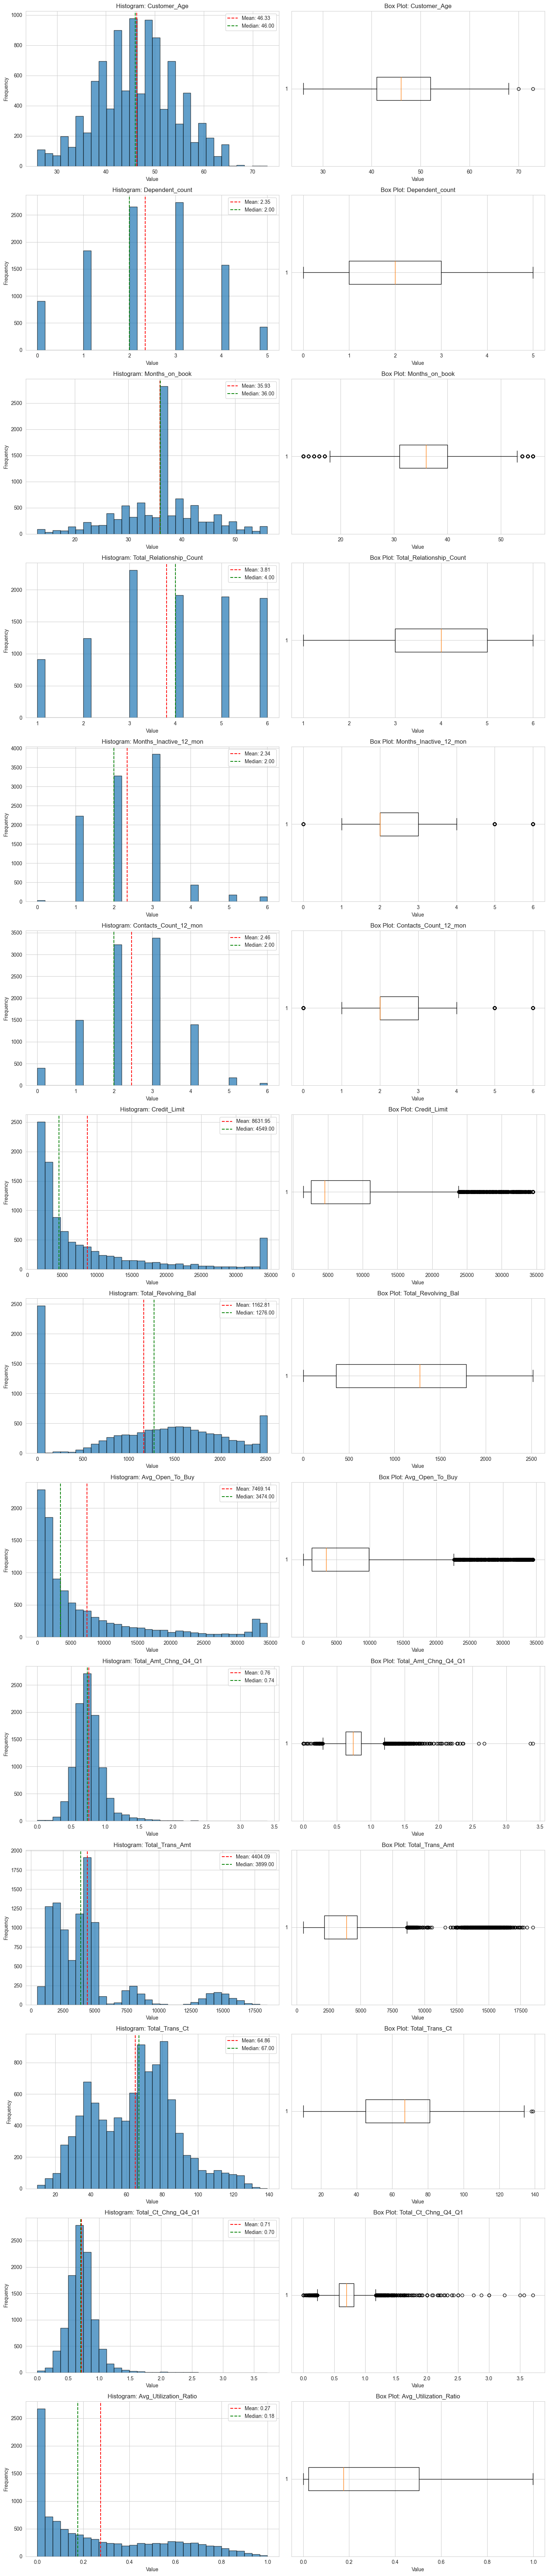

✓ Distribution visualizations created


In [13]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(15, 5*len(numerical_cols)))

for idx, col in enumerate(numerical_cols):
    
    axes[idx, 0].hist(data[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx, 0].axvline(data[col].mean(), color='red', linestyle='--', label=f'Mean: {data[col].mean():.2f}')
    axes[idx, 0].axvline(data[col].median(), color='green', linestyle='--', label=f'Median: {data[col].median():.2f}')
    axes[idx, 0].set_title(f'Histogram: {col}')
    axes[idx, 0].set_xlabel('Value')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].legend()
    
    axes[idx, 1].boxplot(data[col].dropna(), vert=False)
    axes[idx, 1].set_title(f'Box Plot: {col}')
    axes[idx, 1].set_xlabel('Value')

plt.tight_layout()
plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution visualizations created")

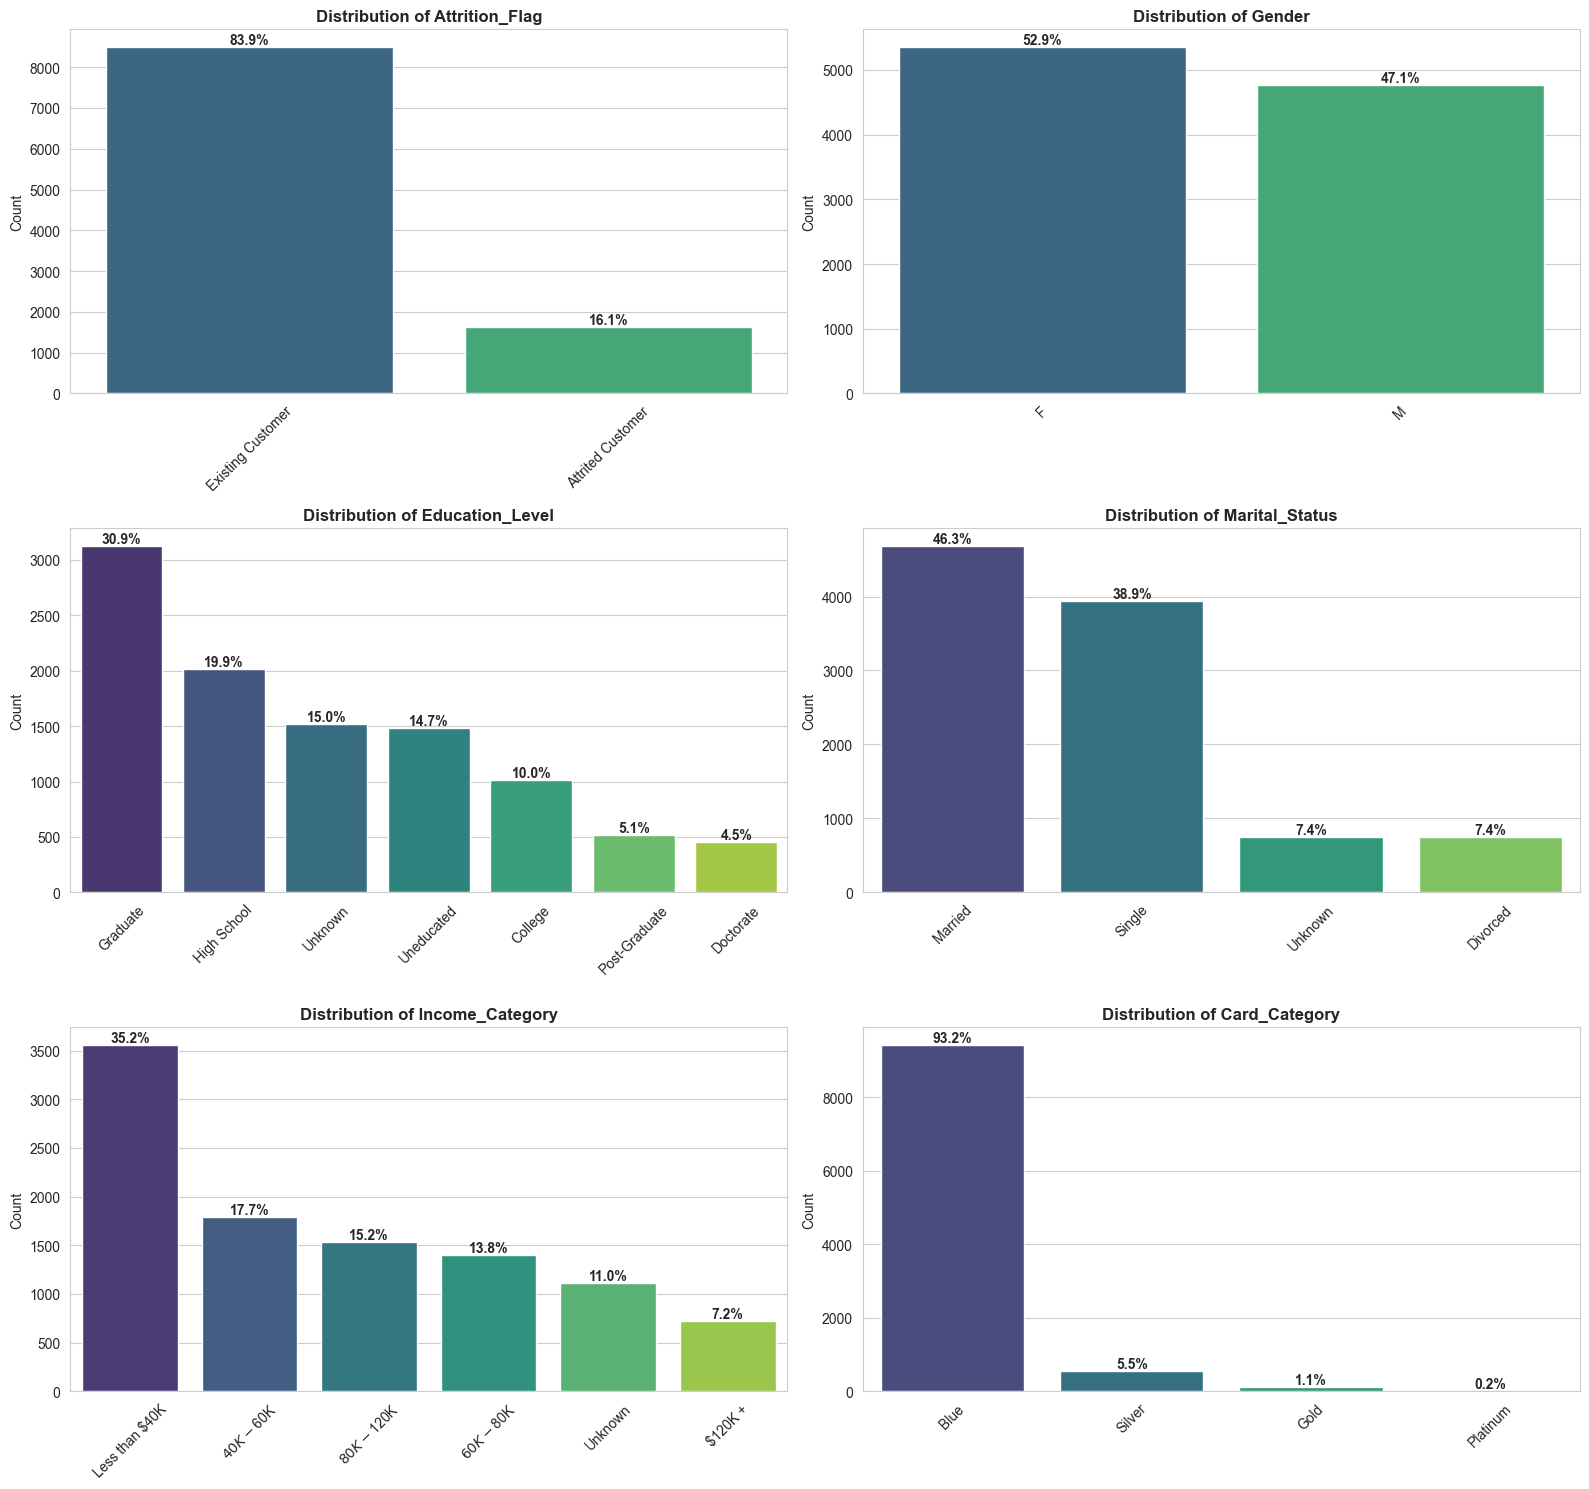

In [14]:
import math

warnings.filterwarnings('ignore')

categorical_cols = data.select_dtypes(include=['object']).columns
total_rows = len(data)

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, ax=ax, palette='viridis', order=order)

    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total_rows)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Ovde se vidi primer nekompletnosti (Completeness) podataka, gde Unknown labela ordinalnih tipova atributa predstavlja sum. Kod Educational Level ovi uzorci mogu biti visokoobrazovani stručnjaci ili ljudi bez škole, a taj podatak drastično menja profil klijenta. Kod Income Category je jos teza situacija jer ostale kategorije prakticno obuhvataju sve moguce vrednosti od Less than 40K do 120K+, sto znaci da ovo nije neka sakrivena (nova) kategorija korisnika, vec grupa ljudi koja nije zelela da da informaciju.


---
# 4. ANALIZA DISTRIBUCIJE I NORMALNOST


In [15]:
def test_normality(data, numerical_cols):

    results = {}
    
    for col in numerical_cols:
        col_data = data[col].dropna()
        
        shapiro_stat, shapiro_p = shapiro(col_data) if len(col_data) < 5000 else (np.nan, np.nan)
        
        ks_stat, ks_p = kstest(col_data, 'norm', args=(col_data.mean(), col_data.std()))
        
        dagostino_stat, dagostino_p = normaltest(col_data)
        
        results[col] = {
            'Shapiro_W': shapiro_stat,
            'Shapiro_p': shapiro_p,
            'KS_stat': ks_stat,
            'KS_p': ks_p,
            'DAgostino_stat': dagostino_stat,
            'DAgostino_p': dagostino_p,
            'Normal': shapiro_p > 0.05 if not np.isnan(shapiro_p) else ks_p > 0.05
        }
    
    return pd.DataFrame(results).T

normality_results = test_normality(data, numerical_cols)

print("="*80)
print("NORMALITY TESTS (p > 0.05 = Normal distribution)")
print("="*80)
print(normality_results.round(4))

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
normal_count = normality_results['Normal'].sum()
print(f"Number of normally distributed attributes: {normal_count}/{len(numerical_cols)}")
print(f"\nNumber of not normally distributed attributes:")
for col in normality_results[~normality_results['Normal']].index:
    print(f"  - {col}")

NORMALITY TESTS (p > 0.05 = Normal distribution)
                         Shapiro_W Shapiro_p   KS_stat KS_p DAgostino_stat  \
Customer_Age                   NaN       NaN  0.028094  0.0      50.082604   
Dependent_count                NaN       NaN  0.159707  0.0     492.781121   
Months_on_book                 NaN       NaN  0.128144  0.0      66.924675   
Total_Relationship_Count       NaN       NaN  0.148526  0.0    2434.458871   
Months_Inactive_12_mon         NaN       NaN  0.195322  0.0     797.458853   
Contacts_Count_12_mon          NaN       NaN  0.182702  0.0       0.206429   
Credit_Limit                   NaN       NaN   0.21433  0.0    2830.070742   
Total_Revolving_Bal            NaN       NaN  0.167082  0.0    5712.189993   
Avg_Open_To_Buy                NaN       NaN  0.205984  0.0    2818.334737   
Total_Amt_Chng_Q4_Q1           NaN       NaN  0.076471  0.0    4293.592243   
Total_Trans_Amt                NaN       NaN  0.248707  0.0    3969.254651   
Total_Trans_Ct 

Dobijeni rezultati nisu najreprezentativniji. Kao sto se ranije vidi na histogramima, za pojedine kolone je bilo ocekivano da dobiju i matematicku potvrdu o odstupanju od normalne distribucije, medjutim, zbog velikog broja uzoraka u datasetu, osetljivost datih algoritama se povecala, a samim i standard normalizacije koju data dstribucija mora da ispunjava da bi se smatrala normalnom. Test je prosao jedino Contacts_Count_12_mon koji ima 0.01 Skew i 0.00 Kurtosis i to bas kod testa koji se oslanja na ove dve vrednosti, dok je ostale delove pao kao diskretna varijabla.<br>
U ovom slucaju korisno bi bilo probati Bootstrapping metod.

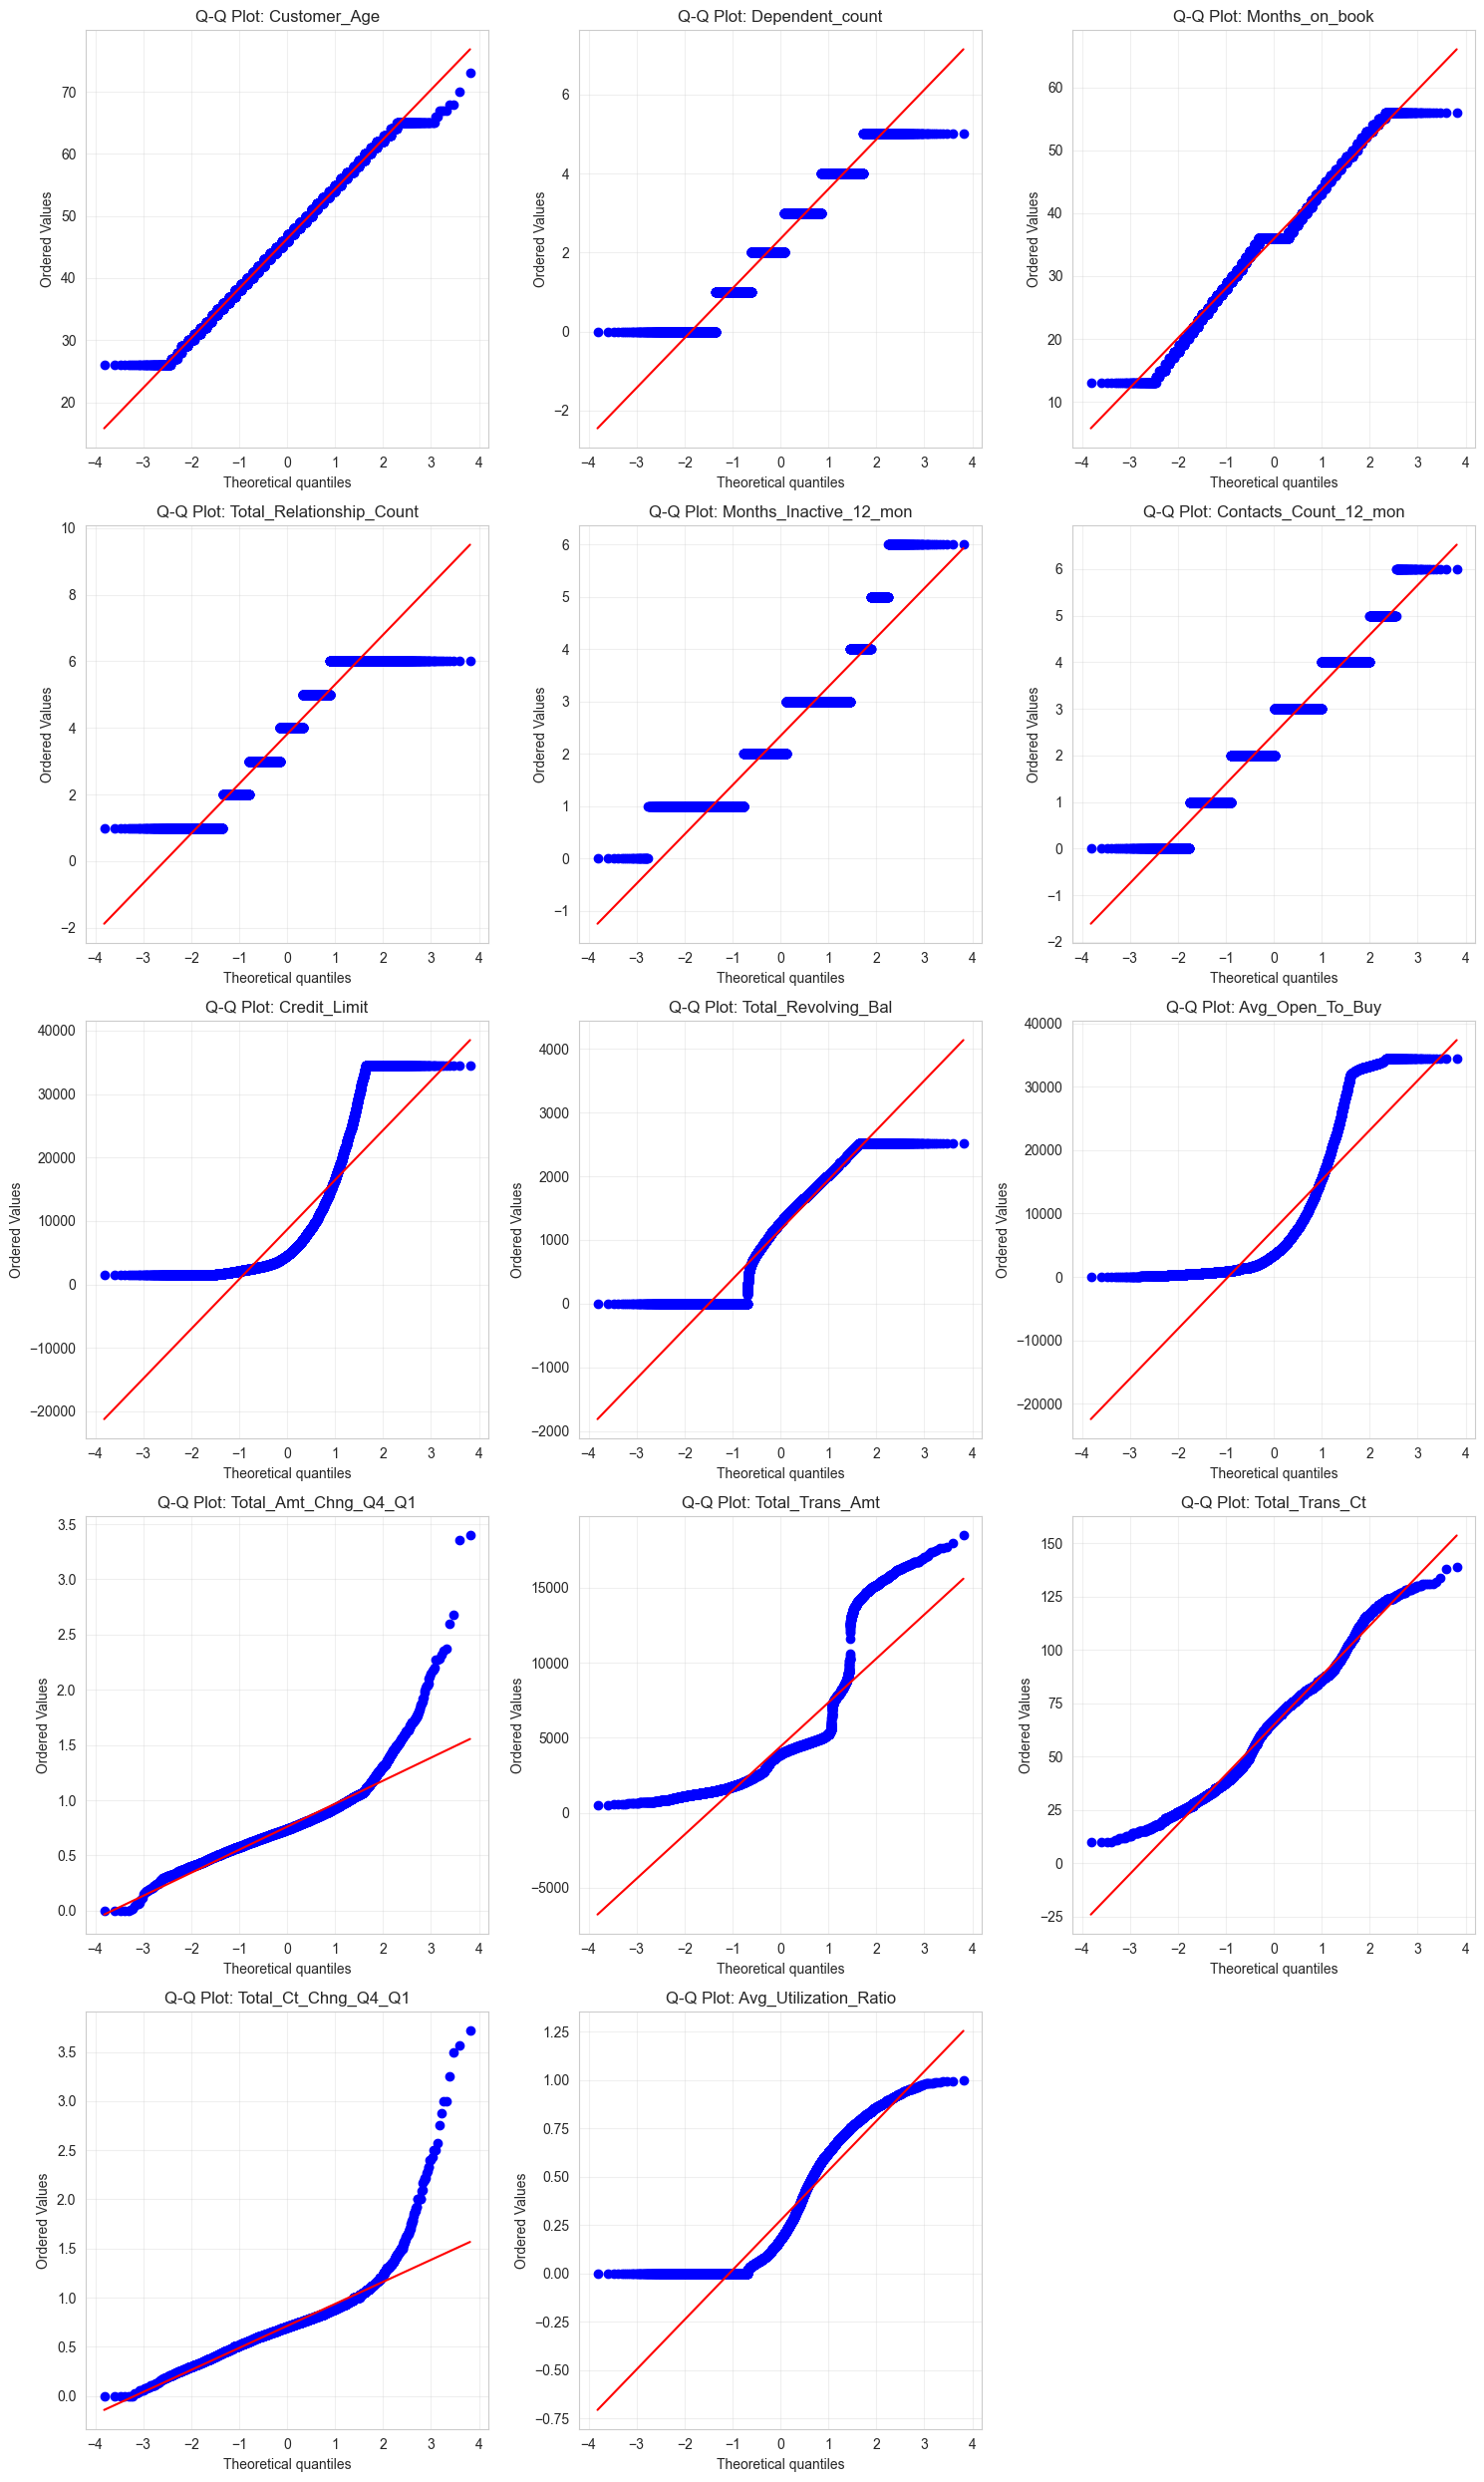

✓ Q-Q plots created


In [16]:
fig, axes = plt.subplots(len(numerical_cols)//3 + 1, 3, figsize=(15, 5*(len(numerical_cols)//3 + 1)))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    stats.probplot(data[col].dropna(), dist="norm", plot=axes[idx])
    axes[idx].set_title(f'Q-Q Plot: {col}')
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('qq_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Q-Q plots created")

---
# 5. ANALIZA KORELACIJE I REDUNDANTNOSTI



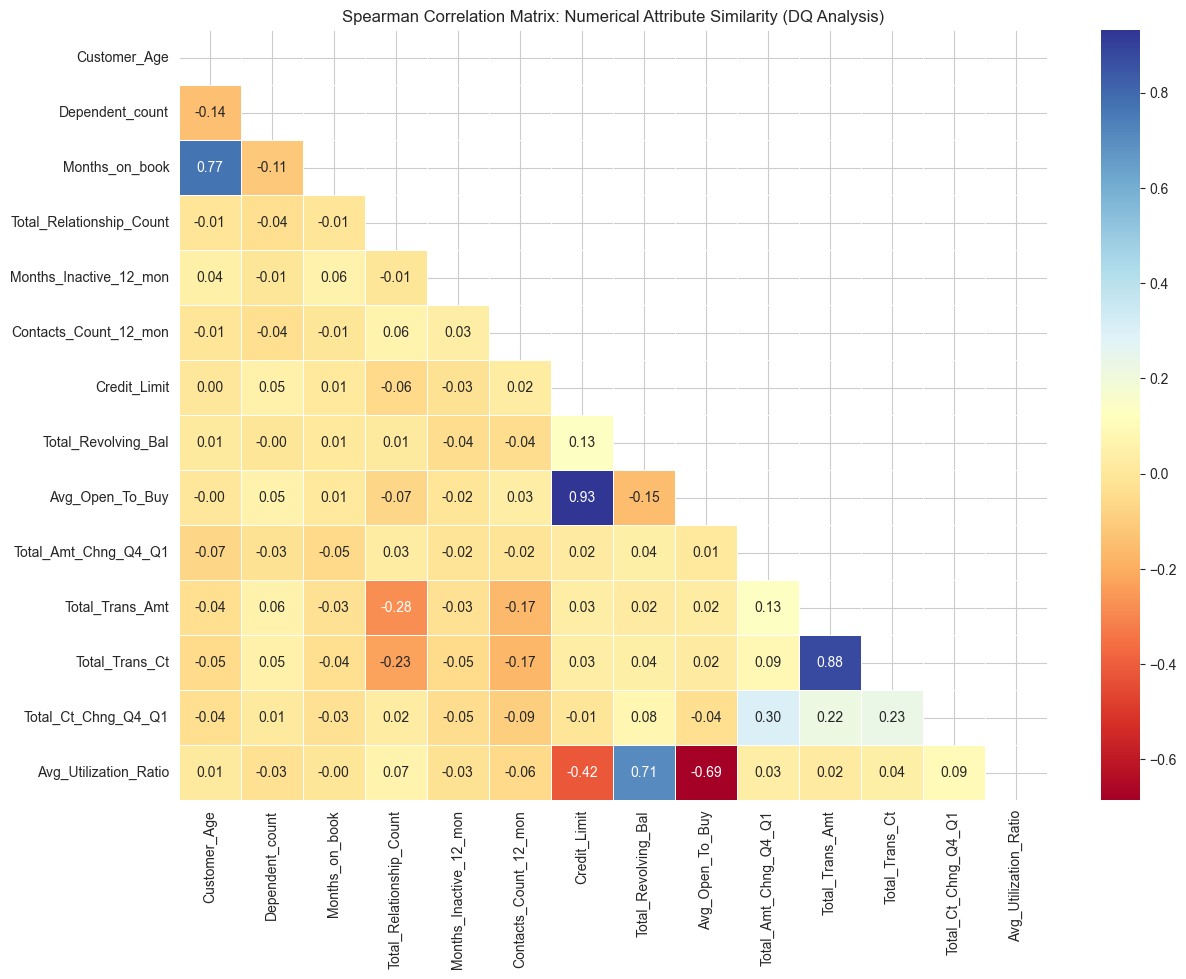

In [17]:
numerical_data = data.select_dtypes(include='number').drop('CLIENTNUM', axis = 1)

spearman_corr = numerical_data.corr(method='spearman')
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr,
            mask=mask,
            annot=True,
            cmap='RdYlBu',
            fmt=".2f",
            linewidths=0.5)

plt.title("Spearman Correlation Matrix: Numerical Attribute Similarity (DQ Analysis)")
plt.show()

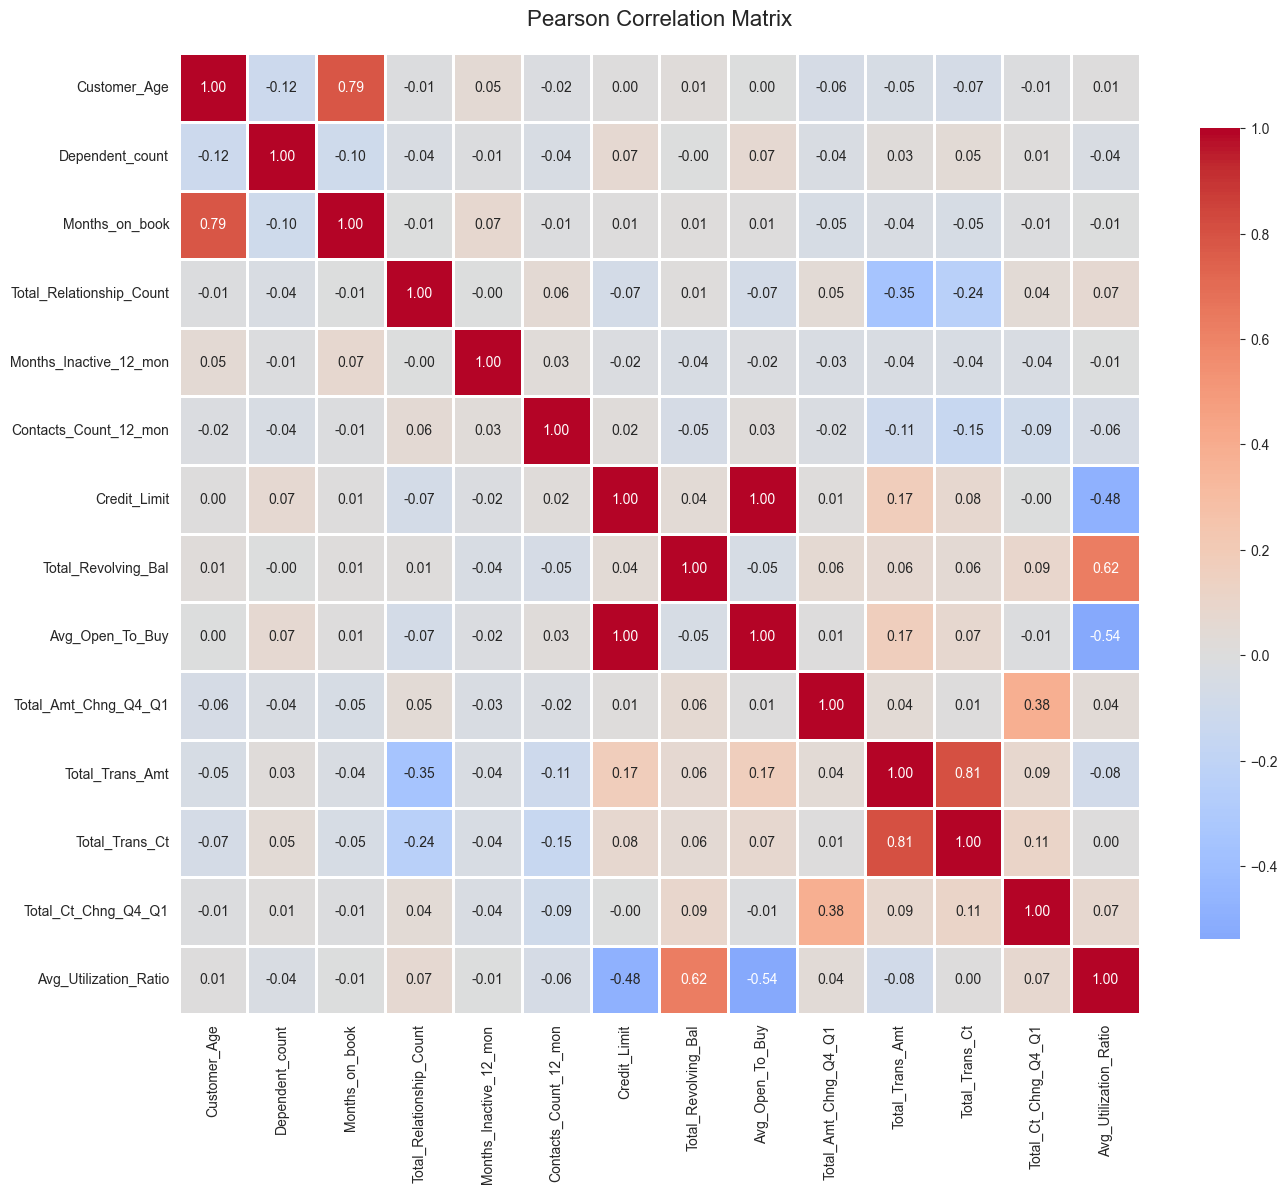

HIGH CORRELATION (|r| > 0.8)
Credit_Limit                   <-> Avg_Open_To_Buy                :  0.996
Total_Trans_Amt                <-> Total_Trans_Ct                 :  0.807


In [18]:
# Pearson Correlation
pearson_corr = data[numerical_cols].corr(method='pearson')

plt.figure(figsize=(14, 12))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Pearson Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('pearson_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Find high correlations (> 0.8)
print("="*80)
print("HIGH CORRELATION (|r| > 0.8)")
print("="*80)
high_corr = []
for i in range(len(pearson_corr.columns)):
    for j in range(i+1, len(pearson_corr.columns)):
        if abs(pearson_corr.iloc[i, j]) > 0.8:
            high_corr.append((pearson_corr.columns[i], pearson_corr.columns[j], pearson_corr.iloc[i, j]))
            print(f"{pearson_corr.columns[i]:30s} <-> {pearson_corr.columns[j]:30s} : {pearson_corr.iloc[i, j]:6.3f}")

if not high_corr:
    print("There are no highly correlated pairs")

1. Consistency
   Total_Trans_Amt vs Total_Trans_Ct (0.88) - logično je da veći broj transakcija generiše veću sumu. Da je ovaj broj nizak, to bi bio alarm da su podaci o transakcijama ili nekompletni ili pogrešno upisani. Ove dve kolone se mogu kasnije upotrebiti za formiranje jedne nove koja ce predstavljati njihov ratio.<br>
   Customer_Age vs Months_on_book (0.77) - ovo potvrđuje hronološku logiku, mladji korisnici ne mogu da provedu mnogo dugacak period u banci kao sto to mogu stariji. Podaci o klijentima nisu nasumično generisani, već prate životni ciklus.
2. Validity
   Avg_Utilization_Ratio vs Credit_Limit (-0.42) vs Total_Revoving_Bal (0.71) vs Avg_Open_To_Buy (-0.69) - ukoliko se ponovo pogleda formula za izracunavanje ovog Ratio-a, sasvim ima smisla da se vrednost smanjuje sa povecanjem vrednosti imenioca, a povecava sa povecanjem vrednosti brojioca, i obrnuto. Visoka negativna korelacija sa Avg_Open_To_Buy, verovatno proizilazi sto iz njene velike korelacije sa Credit_Limit (0.93). <br>
   Credit_Limit vs Avg_Open_To_Buy (0.93) - i na histogramima se moze videti da su im distribucije i opseg vrednosti identicni, s tim sto Avg_Open_To_Buy ima nizi minimum (0). Sa ovolikom korelacijom, ovo je cist kandidat za izbacivanje u Feature selection delu.


In [19]:
# VIF (Variance Inflation Factor) Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, numerical_cols):

    vif_data = pd.DataFrame()
    vif_data["Feature"] = numerical_cols
    
    # Create a subset without NaN
    X = data[numerical_cols].dropna()
    
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(numerical_cols))]
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    return vif_data

vif_results = calculate_vif(data, numerical_cols)

print("="*80)
print("VIF ANALYSIS (VIF > 10 = Serious multicollinearity)")
print("="*80)
print(vif_results.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
problematic = vif_results[vif_results['VIF'] > 10]
if len(problematic) > 0:
    print(f"⚠ {len(problematic)} attributes with VIF > 10 (Serious multicollinearity):")
    for _, row in problematic.iterrows():
        print(f"  - {row['Feature']:30s} : VIF = {row['VIF']:.2f}")
else:
    print("✓ There is no Serious multicollinearity (svi VIF < 10)")

VIF ANALYSIS (VIF > 10 = Serious multicollinearity)
                 Feature       VIF
            Credit_Limit       inf
     Total_Revolving_Bal       inf
         Avg_Open_To_Buy       inf
            Customer_Age 75.090540
          Months_on_book 56.437261
          Total_Trans_Ct 23.199897
    Total_Amt_Chng_Q4_Q1 13.940730
     Total_Ct_Chng_Q4_Q1 11.808382
         Total_Trans_Amt  8.635042
Total_Relationship_Count  7.476147
  Months_Inactive_12_mon  6.084906
   Avg_Utilization_Ratio  5.760124
   Contacts_Count_12_mon  5.538823
         Dependent_count  4.058599

INTERPRETATION
⚠ 8 attributes with VIF > 10 (Serious multicollinearity):
  - Credit_Limit                   : VIF = inf
  - Total_Revolving_Bal            : VIF = inf
  - Avg_Open_To_Buy                : VIF = inf
  - Customer_Age                   : VIF = 75.09
  - Months_on_book                 : VIF = 56.44
  - Total_Trans_Ct                 : VIF = 23.20
  - Total_Amt_Chng_Q4_Q1           : VIF = 13.94
  - Total_Ct

Uočena je generalno visoka multikolinearnost među varijablama u skupu podataka. Validnost ovih rezultata, uprkos nenormalnosti raspodele, opravdava se njihovom konzistentnošću sa Spearmanovom korelacionom matricom, kao i činjenicom da VIF dijagnostikuje udeo zajedničke varijanse nezavisno od distribucije reziduala. Visok VIF (uključujući inf vrednosti) nije neočekivan, s obzirom na to da je većina atributa strukturno i matematički zavisna (npr. izvedene vrednosti limita i duga). Ovaj test služi kao finalna validacija pred korak Feature Reduction-a, kako bi se eliminisala redundantnost koja bi mogla destabilizovati buduće modele.

In [20]:
def chi_square_and_cramers_v(data, categorical_cols):
    """

    Chi-Square: Tests IF association exists (p-value)
    Cramér's V: Measures HOW STRONG the association is (effect size)

    """
    results = []

    for i in range(len(categorical_cols)):
        for j in range(i+1, len(categorical_cols)):
            col1, col2 = categorical_cols[i], categorical_cols[j]

            # Create contingency table
            contingency = pd.crosstab(data[col1], data[col2])

            # Chi-square test
            chi2, p_value, dof, expected = chi2_contingency(contingency)

            # Cramér's V calculation
            n = contingency.sum().sum()  # Total observations
            min_dim = min(contingency.shape[0], contingency.shape[1]) - 1
            cramers_v = np.sqrt(chi2 / (n * min_dim))

            # Interpretation
            if p_value < 0.05:
                if cramers_v < 0.1:
                    strength = "Weak (not practically important)"
                elif cramers_v < 0.3:
                    strength = "Moderate"
                else:
                    strength = "Strong"
            else:
                strength = "Not significant"

            results.append({
                'Variable 1': col1,
                'Variable 2': col2,
                'Chi2': chi2,
                'p-value': p_value,
                'Cramers_V': cramers_v,
                'Statistically_Significant': p_value < 0.05,
                'Strength': strength
            })

    return pd.DataFrame(results)

# Run analysis
association_results = chi_square_and_cramers_v(data, categorical_cols)

print("="*80)
print("CHI-SQUARE + CRAMÉR'S V ANALYSIS (Categorical Variables)")
print("="*80)
print("\nInterpretation:")
print("  Chi-Square p-value < 0.05: Variables are associated")
print("  Cramér's V: 0-0.1 (weak), 0.1-0.3 (moderate), >0.3 (strong)")
print("\n" + "="*80)
print(association_results.round(4).to_string(index=False))

# Filter for meaningful associations
print("\n" + "="*80)
print("MEANINGFUL ASSOCIATIONS (Significant + Moderate/Strong)")
print("="*80)
meaningful = association_results[
    (association_results['Statistically_Significant']) &
    (association_results['Cramers_V'] >= 0.1)
]

if len(meaningful) > 0:
    print(meaningful.round(4).to_string(index=False))
else:
    print("No meaningful associations found")

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total pairs tested: {len(association_results)}")
print(f"Statistically significant (p<0.05): {association_results['Statistically_Significant'].sum()}")
print(f"Weak associations (V<0.1): {(association_results['Cramers_V'] < 0.1).sum()}")
print(f"Moderate associations (0.1≤V<0.3): {((association_results['Cramers_V'] >= 0.1) & (association_results['Cramers_V'] < 0.3)).sum()}")
print(f"Strong associations (V≥0.3): {(association_results['Cramers_V'] >= 0.3).sum()}")


CHI-SQUARE + CRAMÉR'S V ANALYSIS (Categorical Variables)

Interpretation:
  Chi-Square p-value < 0.05: Variables are associated
  Cramér's V: 0-0.1 (weak), 0.1-0.3 (moderate), >0.3 (strong)

     Variable 1      Variable 2      Chi2  p-value  Cramers_V  Statistically_Significant                         Strength
 Attrition_Flag          Gender   13.8656   0.0002     0.0370                       True Weak (not practically important)
 Attrition_Flag Education_Level   12.5112   0.0515     0.0351                      False                  Not significant
 Attrition_Flag  Marital_Status    6.0561   0.1089     0.0245                      False                  Not significant
 Attrition_Flag Income_Category   12.8323   0.0250     0.0356                       True Weak (not practically important)
 Attrition_Flag   Card_Category    2.2342   0.5252     0.0149                      False                  Not significant
         Gender Education_Level    7.2886   0.2950     0.0268                

In [20]:
df_mi = data.copy()

for col in df_mi.select_dtypes(include=['object']).columns:
    df_mi[col] = df_mi[col].astype('category').cat.codes

X = df_mi.drop('Attrition_Flag', axis=1)
y = df_mi['Attrition_Flag']

discrete_features = [X.columns.get_loc(col) for col in X.columns if data[col].dtype == 'object']

mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=13)

mi_results = pd.Series(mi_scores, name="MI Score", index=X.columns)
mi_results = mi_results.sort_values(ascending=False)

print("--- Mutual Information Scores (Target: Attrition_Flag) ---")
print(mi_results)

--- Mutual Information Scores (Target: Attrition_Flag) ---
Total_Trans_Amt             0.158403
Total_Trans_Ct              0.113746
Total_Ct_Chng_Q4_Q1         0.096454
Total_Revolving_Bal         0.087317
Avg_Utilization_Ratio       0.051409
Total_Amt_Chng_Q4_Q1        0.032190
Contacts_Count_12_mon       0.029345
Months_Inactive_12_mon      0.025970
Avg_Open_To_Buy             0.019589
Total_Relationship_Count    0.012663
Credit_Limit                0.005567
CLIENTNUM                   0.004447
Months_on_book              0.003273
Gender                      0.000697
Customer_Age                0.000672
Income_Category             0.000647
Education_Level             0.000587
Marital_Status              0.000299
Card_Category               0.000104
Dependent_count             0.000069
Name: MI Score, dtype: float64


Rezultati Mutual Information testa potvrđuju da transakcioni podaci poseduju najveći informacioni kapacitet u odnosu na ciljnu promenljivu, dok demografski atributi pokazuju nultu ili zanemarljivu informativnost. Ovo opravdava fokusiranje na ponašalne (behavioral) podatke u daljoj analizi kvaliteta.


# 6. DETEKCIJA ANOMALIJA



OUTLIER DETECTION
                          Z-Score (±3σ)  IQR Method  Percentage
Customer_Age                          1           2        0.01
Dependent_count                       0           0        0.00
Months_on_book                        0         386        0.00
Total_Relationship_Count              0           0        0.00
Months_Inactive_12_mon              124         331        1.22
Contacts_Count_12_mon                54         629        0.53
Credit_Limit                          0         984        0.00
Total_Revolving_Bal                   0           0        0.00
Avg_Open_To_Buy                       0         963        0.00
Total_Amt_Chng_Q4_Q1                163         396        1.61
Total_Trans_Amt                     391         896        3.86
Total_Trans_Ct                        2           2        0.02
Total_Ct_Chng_Q4_Q1                 113         394        1.12
Avg_Utilization_Ratio                 0           0        0.00

MAHALANOBIS DISTANCE


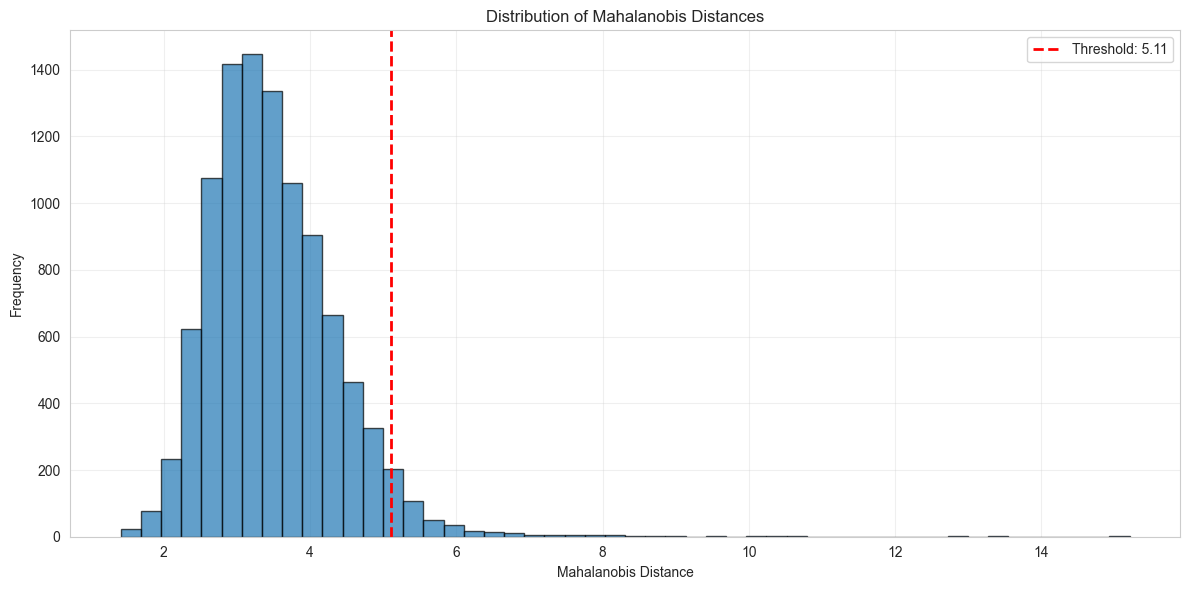

In [21]:
def detect_outliers_zscore(data, numerical_cols, threshold=3):

    outliers = {}
    
    for col in numerical_cols:
        z_scores = np.abs(stats.zscore(data[col].dropna()))
        outlier_indices = np.where(z_scores > threshold)[0]
        outliers[col] = len(outlier_indices)
    
    return pd.Series(outliers)

def detect_outliers_iqr(data, numerical_cols):

    outliers = {}
    
    for col in numerical_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_count = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
        outliers[col] = outlier_count
    
    return pd.Series(outliers)

def detect_outliers_mahalanobis(data, numerical_cols):

    X = data[numerical_cols].dropna()
    
    # Calculate mean and covariance
    mean = X.mean()
    cov = X.cov()
    
    # Calculate Mahalanobis distance
    inv_cov = np.linalg.pinv(cov)  # Use pseudo-inverse for stability
    
    mahal_distances = []
    for idx, row in X.iterrows():
        diff = row - mean
        mahal_dist = np.sqrt(diff @ inv_cov @ diff.T)
        mahal_distances.append(mahal_dist)
    
    mahal_distances = np.array(mahal_distances)
    
    # Threshold: chi-square distribution
    threshold = np.sqrt(stats.chi2.ppf(0.975, len(numerical_cols)))
    outliers = (mahal_distances > threshold).sum()
    
    return outliers, mahal_distances

# Detect outliers using multiple methods
zscore_outliers = detect_outliers_zscore(data, numerical_cols)
iqr_outliers = detect_outliers_iqr(data, numerical_cols)
mahal_outlier_count, mahal_distances = detect_outliers_mahalanobis(data, numerical_cols)

# Combine results
outlier_summary = pd.DataFrame({
    'Z-Score (±3σ)': zscore_outliers,
    'IQR Method': iqr_outliers,
    'Percentage': (zscore_outliers / len(data) * 100).round(2)
})

print("="*80)
print("OUTLIER DETECTION")
print("="*80)
print(outlier_summary.to_string())

print(f"\n{'='*80}")
print(f"MAHALANOBIS DISTANCE")
print(f"{'='*80}")
print(f"Number of detected outliers: {mahal_outlier_count} ({mahal_outlier_count/len(data)*100:.2f}%)")

# Visualize Mahalanobis distances
plt.figure(figsize=(12, 6))
plt.hist(mahal_distances, bins=50, edgecolor='black', alpha=0.7)
threshold = np.sqrt(stats.chi2.ppf(0.975, len(numerical_cols)))
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f}')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Mahalanobis Distances')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mahalanobis_distances.png', dpi=300, bbox_inches='tight')
plt.show()

---
# 7. BASELINE MODEL (PRE PREPROCESIRANJA)



In [22]:

data_baseline = data.copy()

# Encode target variable
le_target = LabelEncoder()
data_baseline['Attrition_Flag'] = le_target.fit_transform(data_baseline['Attrition_Flag'])

# Encode other categorical variables
for col in categorical_cols:
    if col != 'Attrition_Flag':
        le = LabelEncoder()
        data_baseline[col] = le.fit_transform(data_baseline[col])

# Drop CLIENTNUM (ID column)
if 'CLIENTNUM' in data_baseline.columns:
    data_baseline = data_baseline.drop('CLIENTNUM', axis=1)

# Prepare X and y
X_baseline = data_baseline.drop('Attrition_Flag', axis=1)
y_baseline = data_baseline['Attrition_Flag']

# Train-test split
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=13, stratify=y_baseline
)

print("="*80)
print("BASELINE DATA PREPARATION")
print("="*80)
print(f"Training set: {X_train_base.shape}")
print(f"Test set: {X_test_base.shape}")
print(f"\nTarget distribution (train):")
print(y_train_base.value_counts(normalize=True))
print(f"\nTarget distribution (test):")
print(y_test_base.value_counts(normalize=True))

BASELINE DATA PREPARATION
Training set: (8101, 19)
Test set: (2026, 19)

Target distribution (train):
Attrition_Flag
1    0.839279
0    0.160721
Name: proportion, dtype: float64

Target distribution (test):
Attrition_Flag
1    0.839585
0    0.160415
Name: proportion, dtype: float64


BASELINE XGBoost MODEL

Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       0.93      0.84      0.89       325
Existing Customer       0.97      0.99      0.98      1701

         accuracy                           0.96      2026
        macro avg       0.95      0.92      0.93      2026
     weighted avg       0.96      0.96      0.96      2026


BASELINE METRICS SUMMARY
Accuracy       : 0.9650
Precision      : 0.9706
Recall         : 0.9882
F1-Score       : 0.9793
ROC-AUC        : 0.9911


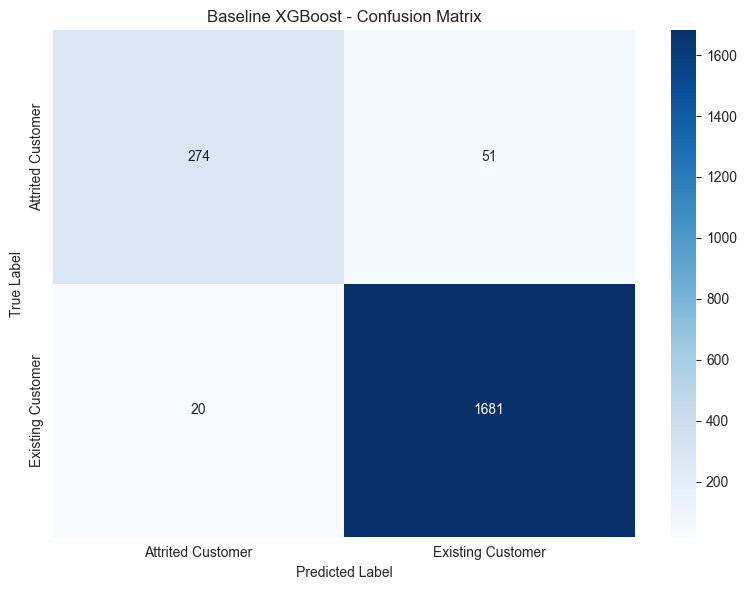


✓ Baseline model trained and evaluated


In [23]:
# Train BASELINE XGBoost model
print("="*80)
print("BASELINE XGBoost MODEL")
print("="*80)

xgb_baseline = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=13,
    eval_metric='logloss'
)

xgb_baseline.fit(X_train_base, y_train_base)
y_pred_baseline = xgb_baseline.predict(X_test_base)
y_pred_proba_baseline = xgb_baseline.predict_proba(X_test_base)[:, 1]

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test_base, y_pred_baseline, target_names=le_target.classes_))

baseline_metrics = {
    'Accuracy': accuracy_score(y_test_base, y_pred_baseline),
    'Precision': precision_score(y_test_base, y_pred_baseline),
    'Recall': recall_score(y_test_base, y_pred_baseline),
    'F1-Score': f1_score(y_test_base, y_pred_baseline),
    'ROC-AUC': roc_auc_score(y_test_base, y_pred_proba_baseline)
}

print("\n" + "="*80)
print("BASELINE METRICS SUMMARY")
print("="*80)
for metric, value in baseline_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

# Confusion Matrix
cm_baseline = confusion_matrix(y_test_base, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Baseline XGBoost - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Baseline model trained and evaluated")

---
# 8. FEATURE ENGINEERING

1. **Interaction Features** - kombinacije postojećih feature-a
2. **Polynomial Features** - nelinearne transformacije
3. **Domain-Specific Features** - kreiranje novih atributa na osnovu domenskog znanja
4. **Binning/Discretization** - kategorizacija numeričkih vrednosti
5. **Ratio Features** - odnosi između varijabli

In [24]:
# Create engineered features
data_engineered = data.copy()

print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# 1. INTERACTION FEATURES
print("\n1. Creating Interaction Features...")

# Credit utilization intensity (interaction between balance and limit)
data_engineered['Credit_Intensity'] = (data_engineered['Total_Revolving_Bal'] * 
                                        data_engineered['Avg_Utilization_Ratio'])

# Customer engagement score (combination of relationship and activity)
data_engineered['Engagement_Score'] = (data_engineered['Total_Relationship_Count'] * 
                                        data_engineered['Total_Trans_Ct'])

# Transaction frequency per relationship
data_engineered['Trans_Per_Relationship'] = (data_engineered['Total_Trans_Ct'] / 
                                               (data_engineered['Total_Relationship_Count'] + 1))

# Average transaction amount
data_engineered['Avg_Trans_Amount'] = (data_engineered['Total_Trans_Amt'] / 
                                        (data_engineered['Total_Trans_Ct'] + 1))

print("  ✓ Created 4 interaction features")

# 2. RATIO FEATURES
print("\n2. Creating Ratio Features...")

# Months per relationship
data_engineered['Months_Per_Relationship'] = (data_engineered['Months_on_book'] / 
                                               (data_engineered['Total_Relationship_Count'] + 1))

# Contact frequency
data_engineered['Contact_Frequency'] = (data_engineered['Contacts_Count_12_mon'] / 
                                         (data_engineered['Months_Inactive_12_mon'] + 1))

# Utilization efficiency
data_engineered['Utilization_Efficiency'] = (data_engineered['Total_Trans_Amt'] / 
                                              (data_engineered['Credit_Limit'] + 1))

# Balance to limit ratio
data_engineered['Balance_To_Limit'] = (data_engineered['Total_Revolving_Bal'] / 
                                        (data_engineered['Credit_Limit'] + 1))

print("  ✓ Created 4 ratio features")

# 3. DOMAIN-SPECIFIC FEATURES
print("\n3. Creating Domain-Specific Features...")

# Customer lifecycle stage (based on tenure)
data_engineered['Lifecycle_Stage'] = pd.cut(data_engineered['Months_on_book'], 
                                             bins=[0, 12, 36, 60, 100], 
                                             labels=['New', 'Growing', 'Mature', 'Veteran'])

# Credit utilization category
data_engineered['Utilization_Category'] = pd.cut(data_engineered['Avg_Utilization_Ratio'], 
                                                   bins=[-0.01, 0.3, 0.7, 1.01], 
                                                   labels=['Low', 'Medium', 'High'])

# Transaction activity level
data_engineered['Activity_Level'] = pd.cut(data_engineered['Total_Trans_Ct'], 
                                            bins=[0, 40, 80, 150], 
                                            labels=['Low', 'Medium', 'High'])

# Customer value segment (based on credit limit and transactions)
limit_terciles = data_engineered['Credit_Limit'].quantile([0.33, 0.67])
trans_terciles = data_engineered['Total_Trans_Amt'].quantile([0.33, 0.67])

data_engineered['Value_Segment'] = 'Medium'
data_engineered.loc[
    (data_engineered['Credit_Limit'] >= limit_terciles[0.67]) & 
    (data_engineered['Total_Trans_Amt'] >= trans_terciles[0.67]), 
    'Value_Segment'
] = 'High'
data_engineered.loc[
    (data_engineered['Credit_Limit'] <= limit_terciles[0.33]) & 
    (data_engineered['Total_Trans_Amt'] <= trans_terciles[0.33]), 
    'Value_Segment'
] = 'Low'

print("  ✓ Created 4 domain-specific features")

# 4. STATISTICAL FEATURES
print("\n4. Creating Statistical Features...")

# Age group
data_engineered['Age_Group'] = pd.cut(data_engineered['Customer_Age'], 
                                       bins=[0, 35, 50, 65, 100], 
                                       labels=['Young', 'Middle', 'Senior', 'Elder'])

# Transaction volatility (using Q4 vs Q1 changes)
data_engineered['Transaction_Volatility'] = (abs(data_engineered['Total_Trans_Ct'] - 
                                               data_engineered['Total_Ct_Chng_Q4_Q1']) /
                                              (data_engineered['Total_Trans_Ct'] + 1))

# Amount change volatility
data_engineered['Amount_Volatility'] = abs(data_engineered['Total_Amt_Chng_Q4_Q1'])

print("  ✓ Created 3 statistical features")

# Summary
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
original_features = len(data.columns)
new_features = len(data_engineered.columns) - original_features
print(f"Original features: {original_features}")
print(f"New features created: {new_features}")
print(f"Total features: {len(data_engineered.columns)}")

print("\nNew Features List:")
new_feature_names = [col for col in data_engineered.columns if col not in data.columns]
for i, feat in enumerate(new_feature_names, 1):
    print(f"  {i:2d}. {feat}")

# Display sample
print("\nSample of engineered features:")
print(data_engineered[new_feature_names[:5]].head())

FEATURE ENGINEERING

1. Creating Interaction Features...
  ✓ Created 4 interaction features

2. Creating Ratio Features...
  ✓ Created 4 ratio features

3. Creating Domain-Specific Features...
  ✓ Created 4 domain-specific features

4. Creating Statistical Features...
  ✓ Created 3 statistical features

FEATURE ENGINEERING SUMMARY
Original features: 21
New features created: 15
Total features: 36

New Features List:
   1. Credit_Intensity
   2. Engagement_Score
   3. Trans_Per_Relationship
   4. Avg_Trans_Amount
   5. Months_Per_Relationship
   6. Contact_Frequency
   7. Utilization_Efficiency
   8. Balance_To_Limit
   9. Lifecycle_Stage
  10. Utilization_Category
  11. Activity_Level
  12. Value_Segment
  13. Age_Group
  14. Transaction_Volatility
  15. Amount_Volatility

Sample of engineered features:
   Credit_Intensity  Engagement_Score  Trans_Per_Relationship  \
0            47.397               210                7.000000   
1            90.720               198                4.7

---
# 9. DATA DRIFT ANALYSIS

**Data drift** je fenomen gde se statistička distribucija podataka menja između training i production okruženja.
Ovo je kritično za kvalitet modela u realnim aplikacijama.

**Metode:**
1. **Population Stability Index (PSI)** - meri promenu u distribuciji
2. **Kolmogorov-Smirnov (KS) Test** - testira da li dve distribucije potiču iz istog procesa
3. **Chi-Square Test** - za kategoričke varijable
4. **Vizuelna inspekcija** - histogrami train vs test

In [25]:
def calculate_psi(expected, actual, bins=10):
    """
    Calculate Population Stability Index (PSI)
    
    PSI < 0.1: No significant change
    0.1 <= PSI < 0.2: Moderate change (monitor)
    PSI >= 0.2: Significant change (investigate)

    """
    # Create bins based on expected distribution
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)  # Remove duplicate values
    
    if len(breakpoints) < 2:
        return 0.0  # Cannot calculate PSI with less than 2 unique values
    
    # Calculate distributions
    expected_percents = pd.cut(expected, bins=breakpoints, include_lowest=True, duplicates='drop').value_counts(normalize=True).sort_index()
    actual_percents = pd.cut(actual, bins=breakpoints, include_lowest=True, duplicates='drop').value_counts(normalize=True).sort_index()
    
    # Align indices
    expected_percents, actual_percents = expected_percents.align(actual_percents, fill_value=0.0001)
    
    # Replace zeros with small value to avoid division by zero
    expected_percents = expected_percents.replace(0, 0.0001)
    actual_percents = actual_percents.replace(0, 0.0001)
    
    # Calculate PSI
    psi_value = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    
    return psi_value

# Prepare train-test split for drift analysis
# Note: We use the engineered dataset
data_drift = data_engineered.copy()

# Encode target
le_target_drift = LabelEncoder()
data_drift['Attrition_Flag'] = le_target_drift.fit_transform(data_drift['Attrition_Flag'])

# Encode categorical features
categorical_drift = data_drift.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_drift:
    le = LabelEncoder()
    data_drift[col] = le.fit_transform(data_drift[col].astype(str))

# Drop ID
if 'CLIENTNUM' in data_drift.columns:
    data_drift = data_drift.drop('CLIENTNUM', axis=1)

# Split
X_drift = data_drift.drop('Attrition_Flag', axis=1)
y_drift = data_drift['Attrition_Flag']

X_train_drift, X_test_drift, y_train_drift, y_test_drift = train_test_split(
    X_drift, y_drift, test_size=0.2, random_state=13, stratify=y_drift
)

print("="*80)
print("DATA DRIFT ANALYSIS - POPULATION STABILITY INDEX (PSI)")
print("="*80)
print("\nInterpretation:")
print("  PSI < 0.1   : No significant change ✓")
print("  0.1 ≤ PSI < 0.2 : Moderate change ⚠")
print("  PSI ≥ 0.2   : Significant change ⚠⚠")
print("\n" + "="*80)

# Calculate PSI for each numerical feature
psi_results = {}
numerical_drift_cols = X_train_drift.select_dtypes(include=[np.number]).columns

for col in numerical_drift_cols:
    psi_value = calculate_psi(X_train_drift[col], X_test_drift[col])
    psi_results[col] = psi_value

psi_df = pd.DataFrame(list(psi_results.items()), columns=['Feature', 'PSI'])
psi_df = psi_df.sort_values('PSI', ascending=False)
psi_df['Status'] = psi_df['PSI'].apply(
    lambda x: 'No change ✓' if x < 0.1 else 'Moderate ⚠' if x < 0.2 else 'Significant ⚠⚠'
)

print(psi_df.to_string(index=False))

# Summary
print("\n" + "="*80)
print("PSI SUMMARY")
print("="*80)
no_change = (psi_df['PSI'] < 0.1).sum()
moderate = ((psi_df['PSI'] >= 0.1) & (psi_df['PSI'] < 0.2)).sum()
significant = (psi_df['PSI'] >= 0.2).sum()

print(f"No change (PSI < 0.1): {no_change} features")
print(f"Moderate change (0.1 ≤ PSI < 0.2): {moderate} features")
print(f"Significant change (PSI ≥ 0.2): {significant} features")

if significant > 0:
    print(f"\n⚠ WARNING: {significant} features show significant drift!")
    print("Features with significant drift:")
    for feat in psi_df[psi_df['PSI'] >= 0.2]['Feature'].values:
        print(f"  - {feat}")
else:
    print("\n✓ No significant drift detected across features")

DATA DRIFT ANALYSIS - POPULATION STABILITY INDEX (PSI)

Interpretation:
  PSI < 0.1   : No significant change ✓
  0.1 ≤ PSI < 0.2 : Moderate change ⚠
  PSI ≥ 0.2   : Significant change ⚠⚠

                 Feature      PSI      Status
            Customer_Age 0.007793 No change ✓
            Credit_Limit 0.007703 No change ✓
     Total_Ct_Chng_Q4_Q1 0.007269 No change ✓
          Total_Trans_Ct 0.006875 No change ✓
       Contact_Frequency 0.006873 No change ✓
        Engagement_Score 0.006718 No change ✓
          Months_on_book 0.006633 No change ✓
         Education_Level 0.005787 No change ✓
         Avg_Open_To_Buy 0.005748 No change ✓
         Total_Trans_Amt 0.005141 No change ✓
    Total_Amt_Chng_Q4_Q1 0.004733 No change ✓
       Amount_Volatility 0.004733 No change ✓
  Transaction_Volatility 0.004620 No change ✓
 Months_Per_Relationship 0.004139 No change ✓
  Utilization_Efficiency 0.003659 No change ✓
  Trans_Per_Relationship 0.003473 No change ✓
        Credit_Intensity 0.00

In [26]:
# Kolmogorov-Smirnov Test for Distribution Drift
print("="*80)
print("KOLMOGOROV-SMIRNOV TEST FOR DISTRIBUTION DRIFT")
print("="*80)
print("\nInterpretation:")
print("  p > 0.05: Distribucije SU iste (no drift) ✓")
print("  p ≤ 0.05: Distribucije NISU iste (drift detected) ⚠")
print("\n" + "="*80)

ks_results = []
for col in numerical_drift_cols:
    ks_stat, ks_pvalue = stats.ks_2samp(X_train_drift[col], X_test_drift[col])
    ks_results.append({
        'Feature': col,
        'KS_Statistic': ks_stat,
        'p-value': ks_pvalue,
        'Drift_Detected': ks_pvalue <= 0.05
    })

ks_df = pd.DataFrame(ks_results)
ks_df = ks_df.sort_values('KS_Statistic', ascending=False)
ks_df['Status'] = ks_df['Drift_Detected'].apply(lambda x: 'Drift ⚠' if x else 'No drift ✓')

print(ks_df.round(4).to_string(index=False))

# Summary
drift_count = ks_df['Drift_Detected'].sum()
print(f"\n{'='*80}")
print(f"KS TEST SUMMARY")
print(f"{'='*80}")
print(f"Features with drift (p ≤ 0.05): {drift_count}/{len(ks_df)}")

if drift_count > 0:
    print(f"\n⚠ WARNING: Drift detected in {drift_count} features!")
else:
    print("\n✓ No drift detected by KS test")

KOLMOGOROV-SMIRNOV TEST FOR DISTRIBUTION DRIFT

Interpretation:
  p > 0.05: Distribucije SU iste (no drift) ✓
  p ≤ 0.05: Distribucije NISU iste (drift detected) ⚠

                 Feature  KS_Statistic  p-value  Drift_Detected     Status
          Marital_Status        0.0276   0.1665           False No drift ✓
         Education_Level        0.0274   0.1731           False No drift ✓
        Credit_Intensity        0.0232   0.3401           False No drift ✓
     Total_Ct_Chng_Q4_Q1        0.0231   0.3477           False No drift ✓
        Avg_Trans_Amount        0.0230   0.3492           False No drift ✓
          Months_on_book        0.0217   0.4255           False No drift ✓
  Utilization_Efficiency        0.0212   0.4530           False No drift ✓
  Transaction_Volatility        0.0200   0.5291           False No drift ✓
       Contact_Frequency        0.0197   0.5484           False No drift ✓
  Trans_Per_Relationship        0.0191   0.5894           False No drift ✓
         T

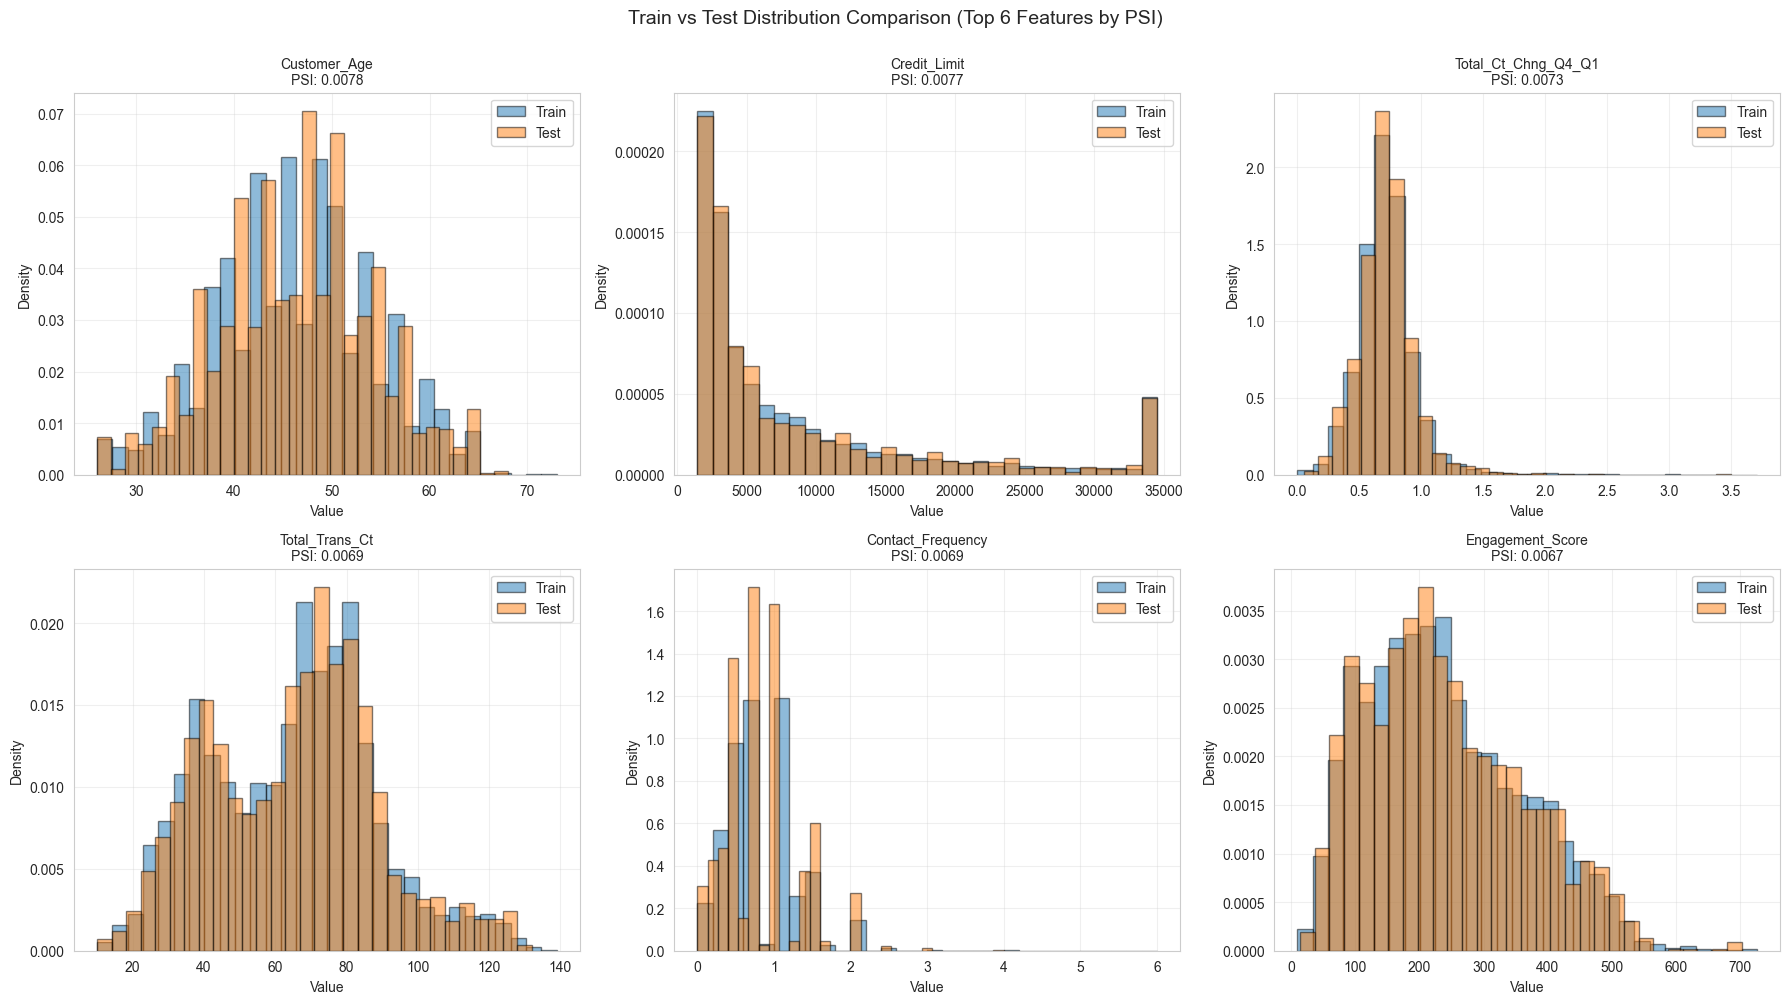

✓ Drift visualization created


In [27]:
# Visualize drift for top features with the highest PSI
top_drift_features = psi_df.nlargest(6, 'PSI')['Feature'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_drift_features):
    axes[idx].hist(X_train_drift[feature], bins=30, alpha=0.5, label='Train', density=True, edgecolor='black')
    axes[idx].hist(X_test_drift[feature], bins=30, alpha=0.5, label='Test', density=True, edgecolor='black')
    axes[idx].set_title(f'{feature}\nPSI: {psi_results[feature]:.4f}', fontsize=10)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Train vs Test Distribution Comparison (Top 6 Features by PSI)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('data_drift_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Drift visualization created")

---
# 10. PREPROCESSING & TRANSFORMACIJE



In [28]:
# Prepare dataset for preprocessing
data_processed = data_engineered.copy()

print("="*80)
print("PREPROCESSING - OUTLIER TREATMENT")
print("="*80)

# 1. OUTLIER TREATMENT using IQR method (Winsorization)
def treat_outliers_iqr(df, numerical_cols, method='winsorize'):

    df_treated = df.copy()
    outlier_report = []
    
    for col in numerical_cols:
        if col in df_treated.columns:
            Q1 = df_treated[col].quantile(0.25)
            Q3 = df_treated[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Count outliers
            outliers = ((df_treated[col] < lower_bound) | (df_treated[col] > upper_bound)).sum()
            
            if method == 'winsorize':
                # Replace outliers with boundary values
                df_treated.loc[df_treated[col] < lower_bound, col] = lower_bound
                df_treated.loc[df_treated[col] > upper_bound, col] = upper_bound
            
            outlier_report.append({
                'Feature': col,
                'Outliers': outliers,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound
            })
    
    return df_treated, pd.DataFrame(outlier_report)

# Get numerical columns for treatment
numerical_for_treatment = data_processed.select_dtypes(include=[np.number]).columns.tolist()
if 'CLIENTNUM' in numerical_for_treatment:
    numerical_for_treatment.remove('CLIENTNUM')

# Treat outliers
data_processed, outlier_report = treat_outliers_iqr(data_processed, numerical_for_treatment, method='winsorize')

print("\nOutlier Treatment Report (Winsorization):")
print(outlier_report.to_string(index=False))

total_outliers = outlier_report['Outliers'].sum()
print(f"\nTotal outliers treated: {total_outliers}")
print("✓ Outliers treated using IQR winsorization")

PREPROCESSING - OUTLIER TREATMENT

Outlier Treatment Report (Winsorization):
                 Feature  Outliers   Lower_Bound  Upper_Bound
            Customer_Age         2     24.500000    68.500000
         Dependent_count         0     -2.000000     6.000000
          Months_on_book       386     17.500000    53.500000
Total_Relationship_Count         0      0.000000     8.000000
  Months_Inactive_12_mon       331      0.500000     4.500000
   Contacts_Count_12_mon       629      0.500000     4.500000
            Credit_Limit       984 -10213.750000 23836.250000
     Total_Revolving_Bal         0  -1778.500000  3921.500000
         Avg_Open_To_Buy       963 -11477.250000 22660.750000
    Total_Amt_Chng_Q4_Q1       396      0.289000     1.201000
         Total_Trans_Amt       896  -1722.750000  8619.250000
          Total_Trans_Ct         2     -9.000000   135.000000
     Total_Ct_Chng_Q4_Q1       394      0.228000     1.172000
   Avg_Utilization_Ratio         0     -0.697000     1.

In [29]:
# 2. BOX-COX TRANSFORMATION for skewed distributions
print("\n" + "="*80)
print("BOX-COX TRANSFORMATION")
print("="*80)

from scipy.stats import boxcox

# Apply Box-Cox to highly skewed features (|skewness| > 1)
skewed_features = stats_df[abs(stats_df['Skewness']) > 1].index.tolist()

print(f"\nFeatures with |Skewness| > 1: {len(skewed_features)}")
print("Applying Box-Cox transformation...\n")

boxcox_report = []
for col in skewed_features:
    if col in data_processed.columns:
        # Box-Cox requires strictly positive values
        min_val = data_processed[col].min()
        if min_val <= 0:
            # Add offset to make all values positive
            offset = abs(min_val) + 1
            data_processed[col] = data_processed[col] + offset
        
        original_skew = data_processed[col].skew()
        
        try:
            # Apply Box-Cox
            transformed, lambda_param = boxcox(data_processed[col])
            data_processed[col] = transformed
            new_skew = pd.Series(transformed).skew()
            
            boxcox_report.append({
                'Feature': col,
                'Original_Skewness': original_skew,
                'New_Skewness': new_skew,
                'Lambda': lambda_param,
                'Improvement': abs(original_skew) - abs(new_skew)
            })
        except Exception as e:
            print(f"  ⚠ Could not transform {col}: {str(e)}")

if boxcox_report:
    boxcox_df = pd.DataFrame(boxcox_report)
    print(boxcox_df.round(4).to_string(index=False))
    print(f"\n✓ Box-Cox transformation applied to {len(boxcox_report)} features")
else:
    print("No features required Box-Cox transformation")


BOX-COX TRANSFORMATION

Features with |Skewness| > 1: 5
Applying Box-Cox transformation...

             Feature  Original_Skewness  New_Skewness  Lambda  Improvement
        Credit_Limit             1.1972        0.0824 -0.2273       1.1149
     Avg_Open_To_Buy             1.1905       -0.0271  0.0778       1.1634
Total_Amt_Chng_Q4_Q1             0.3290        0.0093  0.5965       0.3198
     Total_Trans_Amt             0.8370       -0.0259  0.2056       0.8111
 Total_Ct_Chng_Q4_Q1             0.1291        0.0041  0.8657       0.1249

✓ Box-Cox transformation applied to 5 features


In [30]:
# 3. STANDARDIZATION
print("\n" + "="*80)
print("STANDARDIZATION (Z-Score Normalization)")
print("="*80)

# Encode categorical variables before standardization
data_standardized = data_processed.copy()

# Encode target
le_target_processed = LabelEncoder()
data_standardized['Attrition_Flag'] = le_target_processed.fit_transform(data_standardized['Attrition_Flag'])

# Encode other categorical
categorical_to_encode = data_standardized.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_to_encode:
    le = LabelEncoder()
    data_standardized[col] = le.fit_transform(data_standardized[col].astype(str))


# Drop ID
if 'CLIENTNUM' in data_standardized.columns:
    data_standardized = data_standardized.drop('CLIENTNUM', axis=1)

# Separate features and target
X_processed = data_standardized.drop('Attrition_Flag', axis=1)
y_processed = data_standardized['Attrition_Flag']


# After encoding, VERIFY all columns are numeric
print("\nVerifying data types after encoding...")
print(X_processed.dtypes.value_counts())

# Force conversion if needed
for col in X_processed.columns:
    if X_processed[col].dtype == 'object':
        print(f"⚠ Column {col} is still object type, converting...")
        X_processed[col] = pd.to_numeric(X_processed[col], errors='coerce').fillna(0)

print("✓ All columns verified as numeric")

# Split data
X_train_proc, X_test_proc, y_train_proc, y_test_proc = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=13, stratify=y_processed
)

# Standardize
scaler = StandardScaler()
X_train_proc_scaled = scaler.fit_transform(X_train_proc)
X_test_proc_scaled = scaler.transform(X_test_proc)

# Convert back to DataFrame
X_train_proc_scaled = pd.DataFrame(X_train_proc_scaled, columns=X_train_proc.columns, index=X_train_proc.index)
X_test_proc_scaled = pd.DataFrame(X_test_proc_scaled, columns=X_test_proc.columns, index=X_test_proc.index)

print(f"✓ Features standardized")
print(f"  Training shape: {X_train_proc_scaled.shape}")
print(f"  Test shape: {X_test_proc_scaled.shape}")

# Verify standardization
print("\nPost-standardization statistics (train set):")
print(f"  Mean: {X_train_proc_scaled.mean().mean():.6f} (should be ≈ 0)")
print(f"  Std: {X_train_proc_scaled.std().mean():.6f} (should be ≈ 1)")


STANDARDIZATION (Z-Score Normalization)

Verifying data types after encoding...
float64    20
int32      10
int64       4
Name: count, dtype: int64
✓ All columns verified as numeric
✓ Features standardized
  Training shape: (8101, 34)
  Test shape: (2026, 34)

Post-standardization statistics (train set):
  Mean: 0.000000 (should be ≈ 0)
  Std: 1.000062 (should be ≈ 1)


---
# 11. MODELI POSLE PREPROCESIRANJA


Testiraćemo:
1. XGBoost (isti kao baseline, za direktnu poredbu)
2. LightGBM (modern gradient boosting)
3. CatBoost (handles categorical features natively)

XGBoost AFTER PREPROCESSING

Classification Report:
                   precision    recall  f1-score   support

Attrited Customer       0.92      0.87      0.89       325
Existing Customer       0.97      0.99      0.98      1701

         accuracy                           0.97      2026
        macro avg       0.95      0.93      0.94      2026
     weighted avg       0.97      0.97      0.97      2026


METRICS SUMMARY (After Preprocessing)
Accuracy       : 0.9669
Precision      : 0.9750
Recall         : 0.9859
F1-Score       : 0.9804
ROC-AUC        : 0.9915


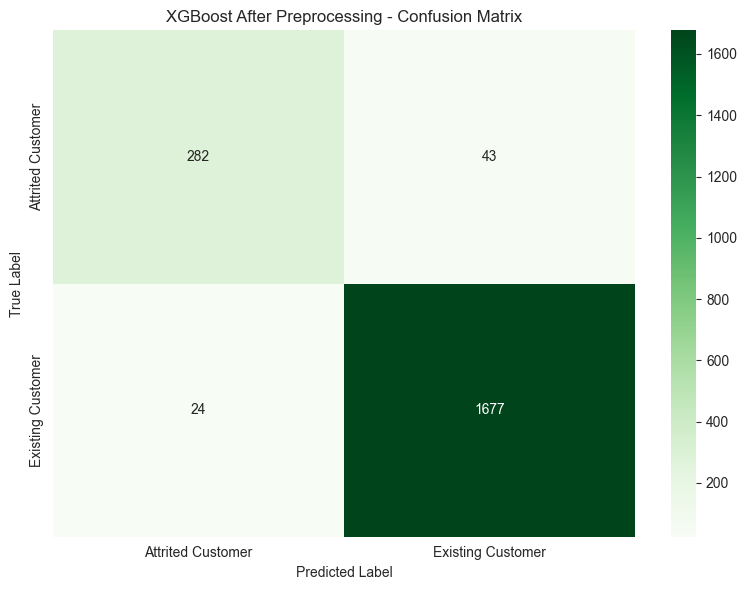


✓ XGBoost model trained on preprocessed data


In [31]:
# XGBoost after preprocessing
print("="*80)
print("XGBoost AFTER PREPROCESSING")
print("="*80)

xgb_processed = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=13,
    eval_metric='logloss'
)

xgb_processed.fit(X_train_proc_scaled, y_train_proc)
y_pred_proc = xgb_processed.predict(X_test_proc_scaled)
y_pred_proba_proc = xgb_processed.predict_proba(X_test_proc_scaled)[:, 1]

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test_proc, y_pred_proc, target_names=le_target_processed.classes_))

processed_metrics = {
    'Accuracy': accuracy_score(y_test_proc, y_pred_proc),
    'Precision': precision_score(y_test_proc, y_pred_proc),
    'Recall': recall_score(y_test_proc, y_pred_proc),
    'F1-Score': f1_score(y_test_proc, y_pred_proc),
    'ROC-AUC': roc_auc_score(y_test_proc, y_pred_proba_proc)
}

print("\n" + "="*80)
print("METRICS SUMMARY (After Preprocessing)")
print("="*80)
for metric, value in processed_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

# Confusion Matrix
cm_processed = confusion_matrix(y_test_proc, y_pred_proc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_processed, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le_target_processed.classes_, yticklabels=le_target_processed.classes_)
plt.title('XGBoost After Preprocessing - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('xgb_processed_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ XGBoost model trained on preprocessed data")

COMPARISON: Baseline vs Preprocessed (XGBoost)

   Metric  Baseline  Preprocessed  Improvement  Improvement_pct
 Accuracy    0.9650        0.9669       0.0020             0.20
Precision    0.9706        0.9750       0.0044             0.46
   Recall    0.9882        0.9859      -0.0024            -0.24
 F1-Score    0.9793        0.9804       0.0011             0.11
  ROC-AUC    0.9911        0.9915       0.0004             0.04


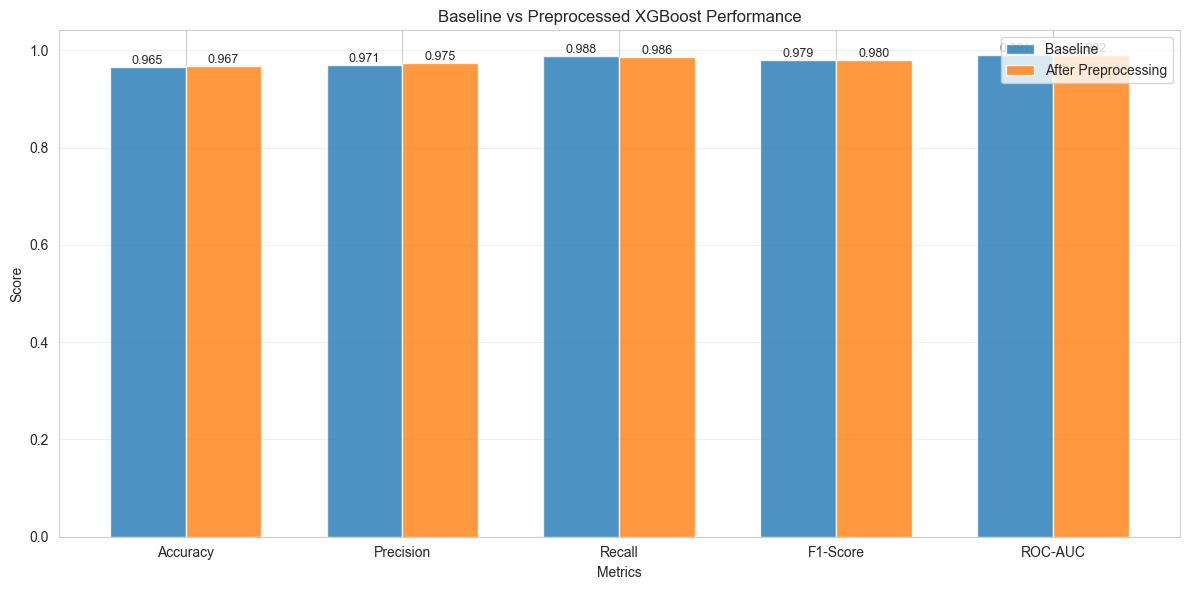


ANALYSIS OF IMPROVEMENT
Accuracy       : 0.9650 → 0.9669 ↑   0.20%
Precision      : 0.9706 → 0.9750 ↑   0.46%
Recall         : 0.9882 → 0.9859 ↓   0.24%
F1-Score       : 0.9793 → 0.9804 ↑   0.11%
ROC-AUC        : 0.9911 → 0.9915 ↑   0.04%


In [32]:
# COMPARISON: Baseline vs Preprocessed
print("="*80)
print("COMPARISON: Baseline vs Preprocessed (XGBoost)")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': list(baseline_metrics.keys()),
    'Baseline': list(baseline_metrics.values()),
    'Preprocessed': list(processed_metrics.values())
})
comparison_df['Improvement'] = comparison_df['Preprocessed'] - comparison_df['Baseline']
comparison_df['Improvement_pct'] = (comparison_df['Improvement'] / comparison_df['Baseline'] * 100).round(2)

print("\n" + comparison_df.round(4).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Baseline'], width, label='Baseline', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['Preprocessed'], width, label='After Preprocessing', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Baseline vs Preprocessed XGBoost Performance')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('baseline_vs_preprocessed_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("ANALYSIS OF IMPROVEMENT")
print("="*80)
for _, row in comparison_df.iterrows():
    symbol = "↑" if row['Improvement'] > 0 else "↓" if row['Improvement'] < 0 else "="
    print(f"{row['Metric']:15s}: {row['Baseline']:.4f} → {row['Preprocessed']:.4f} "
          f"{symbol} {abs(row['Improvement_pct']):6.2f}%")

---
# 12. MODERN ML APPROACHES

**State-of-the-art tehnike:**
1. **LightGBM**
2. **CatBoost**
3. **SHAP**
4. **Optuna**

In [33]:
# LightGBM
print("="*80)
print("LightGBM MODEL")
print("="*80)

try:
    lgbm_model = LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=13,
        verbose=-1
    )
    
    lgbm_model.fit(X_train_proc_scaled, y_train_proc)
    y_pred_lgbm = lgbm_model.predict(X_test_proc_scaled)
    y_pred_proba_lgbm = lgbm_model.predict_proba(X_test_proc_scaled)[:, 1]
    
    lgbm_metrics = {
        'Accuracy': accuracy_score(y_test_proc, y_pred_lgbm),
        'Precision': precision_score(y_test_proc, y_pred_lgbm),
        'Recall': recall_score(y_test_proc, y_pred_lgbm),
        'F1-Score': f1_score(y_test_proc, y_pred_lgbm),
        'ROC-AUC': roc_auc_score(y_test_proc, y_pred_proba_lgbm)
    }
    
    print("\nLightGBM Metrics:")
    for metric, value in lgbm_metrics.items():
        print(f"{metric:15s}: {value:.4f}")
    
    print("\n✓ LightGBM model trained successfully")
    
except NameError:
    print("⚠ LightGBM not installed. Skipping...")
    lgbm_metrics = None

LightGBM MODEL

LightGBM Metrics:
Accuracy       : 0.9640
Precision      : 0.9722
Recall         : 0.9853
F1-Score       : 0.9787
ROC-AUC        : 0.9920

✓ LightGBM model trained successfully


In [34]:
# CatBoost
print("\n" + "="*80)
print("CatBoost MODEL")
print("="*80)

if not globals().get('CATBOOST_AVAILABLE', False):
    print("⚠ CatBoost unavailable. Skipping CatBoost model.")
    catboost_metrics = None
else:
    try:
        catboost_model = CatBoostClassifier(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            random_state=13,
            verbose=False
        )

        catboost_model.fit(X_train_proc_scaled, y_train_proc)
        y_pred_catboost = catboost_model.predict(X_test_proc_scaled)
        y_pred_proba_catboost = catboost_model.predict_proba(X_test_proc_scaled)[:, 1]

        catboost_metrics = {
            'Accuracy': accuracy_score(y_test_proc, y_pred_catboost),
            'Precision': precision_score(y_test_proc, y_pred_catboost),
            'Recall': recall_score(y_test_proc, y_pred_catboost),
            'F1-Score': f1_score(y_test_proc, y_pred_catboost),
            'ROC-AUC': roc_auc_score(y_test_proc, y_pred_proba_catboost)
        }

        print("\nCatBoost Metrics:")
        for metric, value in catboost_metrics.items():
            print(f"{metric:15s}: {value:.4f}")

        print("\n✓ CatBoost model trained successfully")

    except Exception as catboost_train_error:
        print(f"⚠ CatBoost training failed: {catboost_train_error}")
        catboost_metrics = None


CatBoost MODEL

CatBoost Metrics:
Accuracy       : 0.9694
Precision      : 0.9740
Recall         : 0.9900
F1-Score       : 0.9819
ROC-AUC        : 0.9921

✓ CatBoost model trained successfully


### Optuna Hyperparameter Search

**Optuna** - XGBoost hyperparameters.
Optimization target je **ROC-AUC**.

In [35]:
# Optuna Hyperparameter Search (XGBoost)
print("\n" + "="*80)
print("OPTUNA HYPERPARAMETER SEARCH")
print("="*80)

if 'optuna' not in globals():
    print("Optuna is not available. Install with: pip install optuna")
    optuna_metrics = None
else:
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 80, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'random_state': 13,
            'eval_metric': 'logloss',
            'n_jobs': -1
        }

        model = XGBClassifier(**params)
        model.fit(X_train_proc_scaled, y_train_proc)
        y_proba = model.predict_proba(X_test_proc_scaled)[:, 1]
        return roc_auc_score(y_test_proc, y_proba)

    sampler = optuna.samplers.TPESampler(seed=13)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=20, show_progress_bar=False)

    print(f"Best trial ROC-AUC: {study.best_value:.4f}")
    print("Best parameters:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    best_params = study.best_params.copy()
    best_params.update({'random_state': 13, 'eval_metric': 'logloss', 'n_jobs': -1})
    optuna_xgb = XGBClassifier(**best_params)
    optuna_xgb.fit(X_train_proc_scaled, y_train_proc)

    y_pred_optuna = optuna_xgb.predict(X_test_proc_scaled)
    y_pred_proba_optuna = optuna_xgb.predict_proba(X_test_proc_scaled)[:, 1]

    optuna_metrics = {
        'Accuracy': accuracy_score(y_test_proc, y_pred_optuna),
        'Precision': precision_score(y_test_proc, y_pred_optuna),
        'Recall': recall_score(y_test_proc, y_pred_optuna),
        'F1-Score': f1_score(y_test_proc, y_pred_optuna),
        'ROC-AUC': roc_auc_score(y_test_proc, y_pred_proba_optuna)
    }

    print("\nOptuna-tuned XGBoost Metrics:")
    for metric, value in optuna_metrics.items():
        print(f"{metric:15s}: {value:.4f}")


[I 2026-04-05 20:02:15,551] A new study created in memory with name: no-name-bf0deba5-6456-4db6-9730-c1ac93fcf199



OPTUNA HYPERPARAMETER SEARCH


[I 2026-04-05 20:02:15,983] Trial 0 finished with value: 0.9932257043368155 and parameters: {'n_estimators': 251, 'max_depth': 4, 'learning_rate': 0.16502864749998883, 'subsample': 0.9862996792171999, 'colsample_bytree': 0.9890404455619574, 'min_child_weight': 5, 'reg_lambda': 0.2730045285159789}. Best is trial 0 with value: 0.9932257043368155.
[I 2026-04-05 20:02:16,775] Trial 1 finished with value: 0.9925527969972414 and parameters: {'n_estimators': 251, 'max_depth': 8, 'learning_rate': 0.11654897893995354, 'subsample': 0.6140146096405749, 'colsample_bytree': 0.7193797883556717, 'min_child_weight': 1, 'reg_lambda': 2.6806725694093005}. Best is trial 0 with value: 0.9932257043368155.
[I 2026-04-05 20:02:17,288] Trial 2 finished with value: 0.9888590421923755 and parameters: {'n_estimators': 162, 'max_depth': 8, 'learning_rate': 0.023908732902707966, 'subsample': 0.7390324860609968, 'colsample_bytree': 0.6037651080323877, 'min_child_weight': 4, 'reg_lambda': 6.257152311751025}. Best is

Best trial ROC-AUC: 0.9932
Best parameters:
  n_estimators: 251
  max_depth: 4
  learning_rate: 0.16502864749998883
  subsample: 0.9862996792171999
  colsample_bytree: 0.9890404455619574
  min_child_weight: 5
  reg_lambda: 0.2730045285159789

Optuna-tuned XGBoost Metrics:
Accuracy       : 0.9669
Precision      : 0.9750
Recall         : 0.9859
F1-Score       : 0.9804
ROC-AUC        : 0.9932



SHAP ANALYSIS (Model Interpretability)

✓ All columns already numeric

Creating SHAP explainer (this may take 1-2 minutes)...
Calculating SHAP values for 1000 samples...

Generating SHAP visualizations...


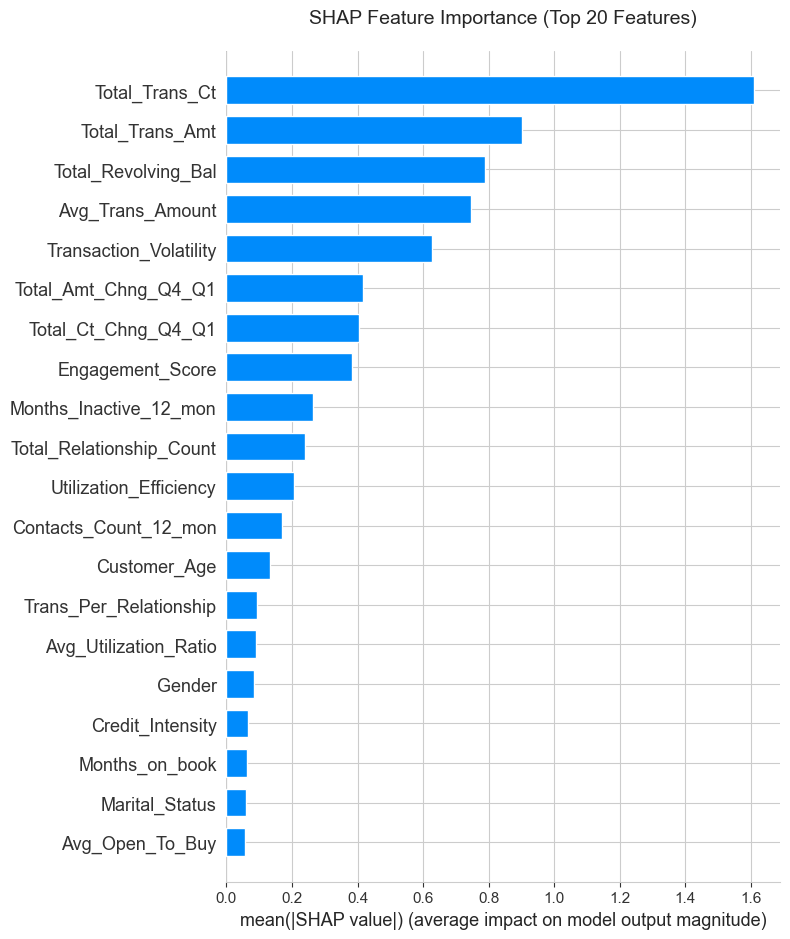

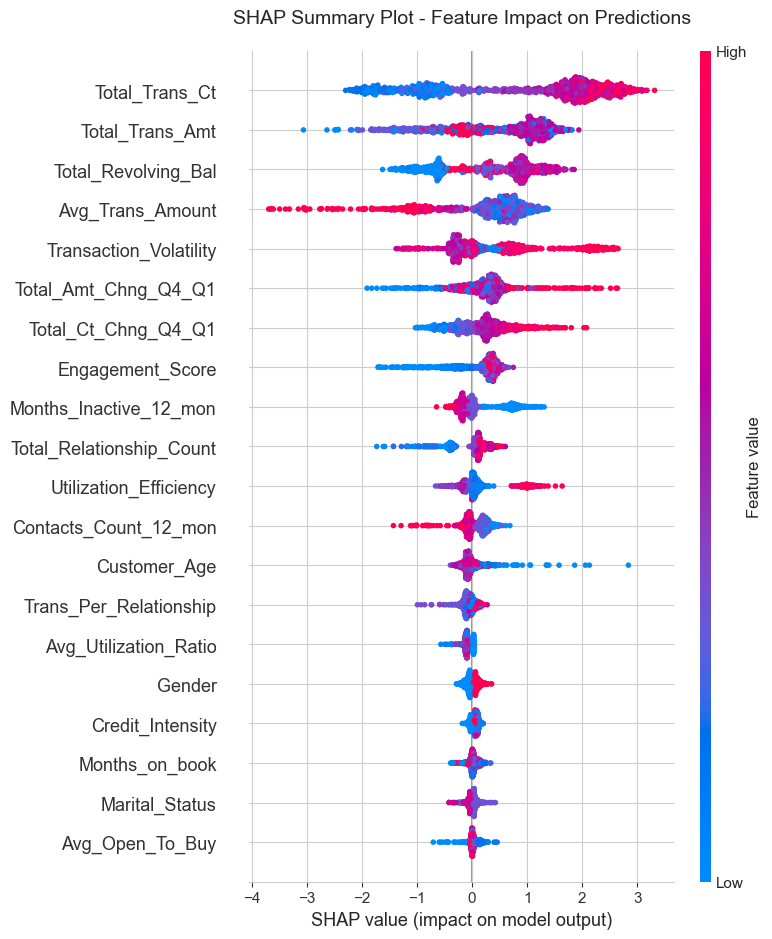


TOP 15 MOST IMPORTANT FEATURES (by SHAP)
                 Feature  Importance
          Total_Trans_Ct    1.609069
         Total_Trans_Amt    0.901107
     Total_Revolving_Bal    0.788950
        Avg_Trans_Amount    0.746748
  Transaction_Volatility    0.627657
    Total_Amt_Chng_Q4_Q1    0.417731
     Total_Ct_Chng_Q4_Q1    0.405312
        Engagement_Score    0.383233
  Months_Inactive_12_mon    0.263492
Total_Relationship_Count    0.240654
  Utilization_Efficiency    0.206130
   Contacts_Count_12_mon    0.168730
            Customer_Age    0.132206
  Trans_Per_Relationship    0.091986
   Avg_Utilization_Ratio    0.088651

✓ SHAP analysis completed successfully

Interpretacija:
- Crvene tačke = visoka vrednost feature-a
- Plave tačke = niska vrednost feature-a
- Pozicija na x-osi = uticaj na predikciju (pozitivan ili negativan)
- Veća apsolutna vrednost = važniji feature


In [36]:
# SHAP Analysis for Interpretability
print("\n" + "="*80)
print("SHAP ANALYSIS (Model Interpretability)")
print("="*80)

try:
    # CRITICAL FIX: Ensure all data is numeric
    # Check for non-numeric columns
    non_numeric = X_test_proc_scaled.select_dtypes(include=['object', 'category']).columns

    if len(non_numeric) > 0:
        print(f"\n⚠ Found {len(non_numeric)} non-numeric columns:")
        for col in non_numeric:
            print(f"  - {col}: {X_test_proc_scaled[col].dtype}")

        # Convert to numeric (should already be done, but safety check)
        X_test_shap = X_test_proc_scaled.copy()
        for col in non_numeric:
            X_test_shap[col] = pd.to_numeric(X_test_shap[col], errors='coerce')

        # Fill any NaN created by conversion
        X_test_shap = X_test_shap.fillna(0)
        print("\n✓ Converted all columns to numeric for SHAP")
    else:
        X_test_shap = X_test_proc_scaled.copy()
        print("\n✓ All columns already numeric")

    # Additional safety: Convert to numpy array and ensure float type
    X_test_shap_array = X_test_shap.values.astype(np.float64)

    # Create SHAP explainer for XGBoost
    print("\nCreating SHAP explainer (this may take 1-2 minutes)...")
    explainer = shap.TreeExplainer(xgb_processed)

    # Calculate SHAP values (use smaller sample if dataset is large)
    sample_size = min(1000, len(X_test_shap_array))
    print(f"Calculating SHAP values for {sample_size} samples...")
    shap_values = explainer.shap_values(X_test_shap_array[:sample_size])

    # SHAP values might be 2D for binary classification, take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Class 1 (Attrited Customer)

    # Summary plot (bar) - Feature Importance
    print("\nGenerating SHAP visualizations...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        X_test_shap.iloc[:sample_size],
        plot_type="bar",
        show=False,
        max_display=20  # Show top 20 features
    )
    plt.title('SHAP Feature Importance (Top 20 Features)', fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Detailed summary plot - Feature Impact
    plt.figure(figsize=(12, 10))
    shap.summary_plot(
        shap_values,
        X_test_shap.iloc[:sample_size],
        show=False,
        max_display=20
    )
    plt.title('SHAP Summary Plot - Feature Impact on Predictions', fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Feature importance ranking
    feature_importance = pd.DataFrame({
        'Feature': X_test_shap.columns,
        'Importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('Importance', ascending=False)

    print("\n" + "="*80)
    print("TOP 15 MOST IMPORTANT FEATURES (by SHAP)")
    print("="*80)
    print(feature_importance.head(15).to_string(index=False))

    print("\n✓ SHAP analysis completed successfully")
    print("\nInterpretacija:")
    print("- Crvene tačke = visoka vrednost feature-a")
    print("- Plave tačke = niska vrednost feature-a")
    print("- Pozicija na x-osi = uticaj na predikciju (pozitivan ili negativan)")
    print("- Veća apsolutna vrednost = važniji feature")

except ImportError:
    print("⚠ SHAP not installed. Install with: pip install shap")
except Exception as e:
    print(f"⚠ SHAP analysis failed: {str(e)}")
    print("\nDebug information:")
    print(f"X_test_proc_scaled shape: {X_test_proc_scaled.shape}")
    print(f"X_test_proc_scaled dtypes:\n{X_test_proc_scaled.dtypes}")
    print("\nTrying alternative: Feature Importance from XGBoost...")

    # Fallback: Use XGBoost's built-in feature importance
    try:
        feature_importance = pd.DataFrame({
            'Feature': X_test_proc_scaled.columns,
            'Importance': xgb_processed.feature_importances_
        }).sort_values('Importance', ascending=False)

        plt.figure(figsize=(12, 8))
        plt.barh(feature_importance.head(20)['Feature'],
                 feature_importance.head(20)['Importance'])
        plt.xlabel('Importance')
        plt.title('XGBoost Feature Importance (Top 20)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\n✓ Using XGBoost feature importance instead")
        print("\nTop 15 Features:")
        print(feature_importance.head(15).to_string(index=False))

    except Exception as e2:
        print(f"⚠ Fallback also failed: {str(e2)}")

---
# 13. AutoML (H2O)


H2O AutoML

Initializing H2O cluster...
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 26+35-2893, mixed mode, sharing)
  Starting server from D:\Programs\anaconda3\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\Korisnik\AppData\Local\Temp\tmp3gz89p0c
  JVM stdout: C:\Users\Korisnik\AppData\Local\Temp\tmp3gz89p0c\h2o_Korisnik_started_from_python.out
  JVM stderr: C:\Users\Korisnik\AppData\Local\Temp\tmp3gz89p0c\h2o_Korisnik_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Belgrade
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,4 months and 12 days
H2O_cluster_name:,H2O_from_python_Korisnik_p5cm5d
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.985 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"



H2O Cluster Configuration:


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Belgrade
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,4 months and 12 days
H2O_cluster_name:,H2O_from_python_Korisnik_p5cm5d
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.985 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


Nodes info:,Node 1
h2o,/127.0.0.1:54321
healthy,True
last_ping,1775400710580.0000000
num_cpus,12
sys_load,0.0
mem_value_size,0
free_mem,4278801760.0000000
pojo_mem,16165536
swap_mem,0
free_disk,18937282560.0000000


Available cores: 1

Preparing data for H2O...
Ensuring all data is numeric...
Converting to H2O frames...
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%

Features: 34
Training samples: 8101
Test samples: 2026

Training AutoML models (this may take 5-10 minutes)...
AutoML progress: |
16:51:53.294: Project: AutoML_1_20260405_165153
16:51:53.299: Setting stopping tolerance adaptively based on the training frame: 0.011110425303554916
16:51:53.299: Build control seed: 13
16:51:53.300: training frame: Frame key: AutoML_1_20260405_165153_training_py_1_sid_9fc2    cols: 35    rows: 8101  chunks: 2    size: 1294196  checksum: 1238383164161125466
16:51:53.301: validation frame: NULL
16:51:53.302: leaderboard frame: Frame key: py_2_sid_9fc2    cols: 35    rows: 2026  chunks: 1    size: 327008  checksum: -6642202410877827001
16:51:53.302: blending frame: NU

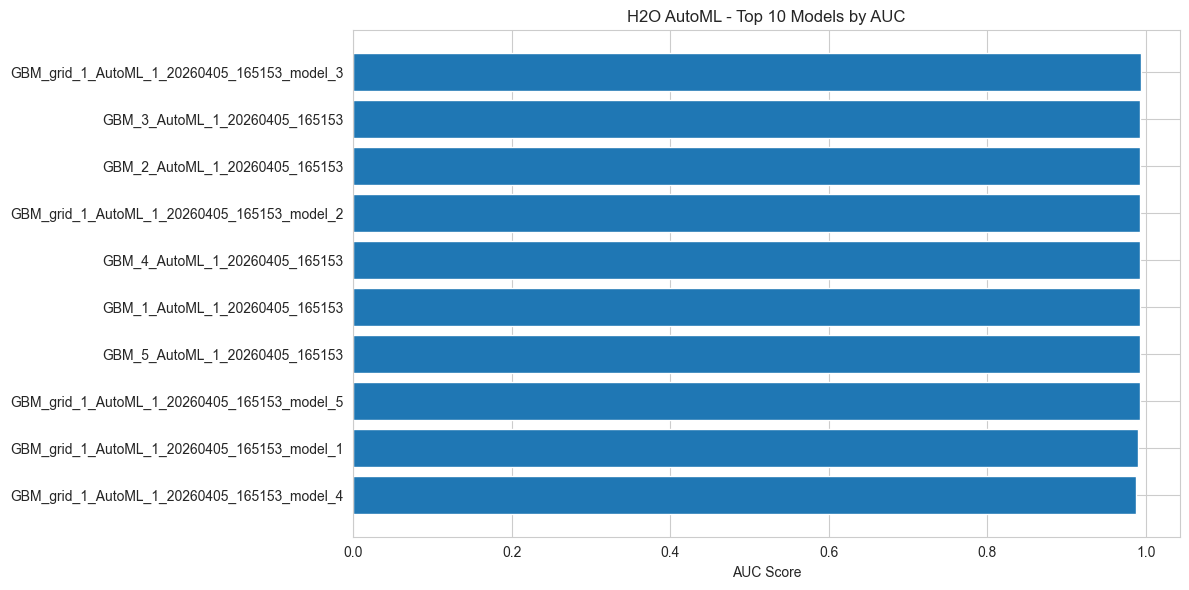


✓ H2O AutoML completed successfully
  Models trained: 15
  Best AUC: 0.9935
H2O session _sid_9fc2 closed.


In [39]:
# H2O AutoML
print("="*80)
print("H2O AutoML")
print("="*80)

try:
    import h2o
    from h2o.automl import H2OAutoML

    # Shutdown any existing H2O instance
    try:
        h2o.cluster().shutdown(prompt=False)
        import time
        time.sleep(2)  # Wait for cleanup
    except:
        pass

    # Initialize H2O with explicit settings
    print("\nInitializing H2O cluster...")
    h2o.init(
        nthreads=-1,        # Use all available cores
        max_mem_size='4G',  # Allocate 4GB RAM (adjust based on your system)
        strict_version_check=False
    )

    # Verify cluster configuration
    print("\nH2O Cluster Configuration:")
    cluster_info = h2o.cluster().show_status(True)

    # Check cores
    cores = h2o.cluster().cloud_size
    print(f"Available cores: {cores}")
    if cores == 0:
        print("⚠ WARNING: No cores detected. H2O may run in limited mode.")
        print("  This will severely limit model training.")
        print("  Recommendation: Restart Python kernel and try again.")

    # Prepare data for H2O
    print("\nPreparing data for H2O...")
    train_h2o_data = X_train_proc_scaled.copy()
    train_h2o_data['Attrition_Flag'] = y_train_proc.values

    test_h2o_data = X_test_proc_scaled.copy()
    test_h2o_data['Attrition_Flag'] = y_test_proc.values

    # Ensure all columns are numeric (critical!)
    print("Ensuring all data is numeric...")
    for col in train_h2o_data.columns:
        if train_h2o_data[col].dtype == 'object':
            train_h2o_data[col] = pd.to_numeric(train_h2o_data[col], errors='coerce').fillna(0)
            test_h2o_data[col] = pd.to_numeric(test_h2o_data[col], errors='coerce').fillna(0)

    # Convert to H2O frames
    print("Converting to H2O frames...")
    train_hf = h2o.H2OFrame(train_h2o_data)
    test_hf = h2o.H2OFrame(test_h2o_data)

    # Set target as factor (categorical)
    train_hf['Attrition_Flag'] = train_hf['Attrition_Flag'].asfactor()
    test_hf['Attrition_Flag'] = test_hf['Attrition_Flag'].asfactor()

    # Define predictors and response
    y_col = "Attrition_Flag"
    x_cols = [col for col in train_hf.columns if col != y_col]

    print(f"\nFeatures: {len(x_cols)}")
    print(f"Training samples: {train_hf.nrow}")
    print(f"Test samples: {test_hf.nrow}")

    # Run AutoML with better configuration
    print("\n" + "="*80)
    print("Training AutoML models (this may take 5-10 minutes)...")
    print("="*80)

    aml = H2OAutoML(
        max_models=20,              # Train up to 20 models
        max_runtime_secs=600,       # 10 minutes max
        seed=13,
        balance_classes=True,       # Handle imbalanced data
        nfolds=5,                   # 5-fold cross-validation
        keep_cross_validation_predictions=True,
        sort_metric='AUC',          # Optimize for AUC
        verbosity='info'            # Show progress
    )

    # Train
    aml.train(x=x_cols, y=y_col, training_frame=train_hf, leaderboard_frame=test_hf)

    # Leaderboard
    lb = aml.leaderboard
    print("\n" + "="*80)
    print("H2O AutoML LEADERBOARD (Top 10 Models)")
    print("="*80)
    print(lb.head(rows=min(10, lb.nrows)))

    # Best model details
    best_model = aml.leader
    print(f"\n{'='*80}")
    print(f"BEST MODEL: {best_model.model_id}")
    print(f"{'='*80}")

    # Model performance on test set
    perf = best_model.model_performance(test_hf)
    print(f"\nTest Set Performance:")
    print(f"  AUC: {perf.auc():.4f}")
    print(f"  Accuracy: {perf.accuracy()[0][1]:.4f}")
    print(f"  Logloss: {perf.logloss():.4f}")

    # Save leaderboard
    lb_df = lb.as_data_frame()
    lb_df.to_csv('h2o_automl_leaderboard.csv', index=False)
    print("\n✓ Leaderboard saved to h2o_automl_leaderboard.csv")

    # Visualization
    if lb.nrows > 1:
        plt.figure(figsize=(12, 6))
        top_10 = lb_df.head(10)
        plt.barh(range(len(top_10)), top_10['auc'])
        plt.yticks(range(len(top_10)), top_10['model_id'])
        plt.xlabel('AUC Score')
        plt.title('H2O AutoML - Top 10 Models by AUC')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('h2o_automl_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

    print(f"\n✓ H2O AutoML completed successfully")
    print(f"  Models trained: {lb.nrows}")
    print(f"  Best AUC: {lb[0, 'auc']:.4f}")

    # Shutdown H2O
    h2o.cluster().shutdown(prompt=False)

except ImportError:
    print("⚠ H2O not installed. Install with: pip install h2o")
    print("  Note: H2O requires Java 8 or higher")
except Exception as e:
    print(f"⚠ H2O AutoML failed: {str(e)}")
    print("\nPossible causes:")
    print("1. Java not installed or not in PATH")
    print("2. Insufficient memory (try reducing max_mem_size)")
    print("3. Port 54321 already in use")
    print("4. Data type issues (check all columns are numeric)")

    # Try to shutdown H2O even if failed
    try:
        h2o.cluster().shutdown(prompt=False)
    except:
        pass

---
# 14. UPOREDNA ANALIZA REZULTATA


FINALNA UPOREDNA ANALIZA SVIH MODELA

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Baseline XGBoost    0.9650     0.9706  0.9882    0.9793   0.9911
XGBoost (Preprocessed)    0.9669     0.9750  0.9859    0.9804   0.9915
              LightGBM    0.9640     0.9722  0.9853    0.9787   0.9920
              CatBoost    0.9694     0.9740  0.9900    0.9819   0.9921
      XGBoost (Optuna)    0.9669     0.9750  0.9859    0.9804   0.9932

NAJBOLJI MODEL: XGBoost (Optuna)
ROC-AUC: 0.9932


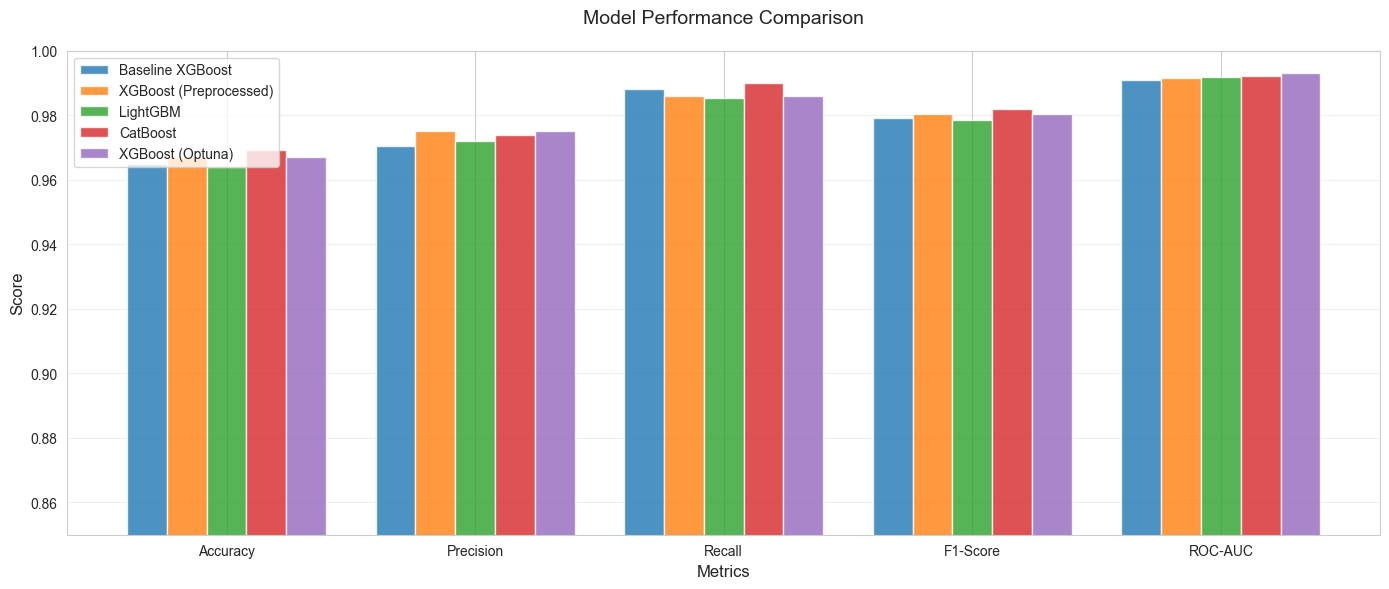


✓ Final comparison completed


In [38]:
# Compile all results
print("="*80)
print("FINALNA UPOREDNA ANALIZA SVIH MODELA")
print("="*80)

results_summary = pd.DataFrame({
    'Model': ['Baseline XGBoost', 'XGBoost (Preprocessed)'],
    'Accuracy': [baseline_metrics['Accuracy'], processed_metrics['Accuracy']],
    'Precision': [baseline_metrics['Precision'], processed_metrics['Precision']],
    'Recall': [baseline_metrics['Recall'], processed_metrics['Recall']],
    'F1-Score': [baseline_metrics['F1-Score'], processed_metrics['F1-Score']],
    'ROC-AUC': [baseline_metrics['ROC-AUC'], processed_metrics['ROC-AUC']]
})

# Add LightGBM if available
if lgbm_metrics:
    results_summary = pd.concat([results_summary, pd.DataFrame({
        'Model': ['LightGBM'],
        'Accuracy': [lgbm_metrics['Accuracy']],
        'Precision': [lgbm_metrics['Precision']],
        'Recall': [lgbm_metrics['Recall']],
        'F1-Score': [lgbm_metrics['F1-Score']],
        'ROC-AUC': [lgbm_metrics['ROC-AUC']]
    })], ignore_index=True)

# Add CatBoost if available
if catboost_metrics:
    results_summary = pd.concat([results_summary, pd.DataFrame({
        'Model': ['CatBoost'],
        'Accuracy': [catboost_metrics['Accuracy']],
        'Precision': [catboost_metrics['Precision']],
        'Recall': [catboost_metrics['Recall']],
        'F1-Score': [catboost_metrics['F1-Score']],
        'ROC-AUC': [catboost_metrics['ROC-AUC']]
    })], ignore_index=True)

# Add Optuna-tuned XGBoost if available
if globals().get('optuna_metrics'):
    results_summary = pd.concat([results_summary, pd.DataFrame({
        'Model': ['XGBoost (Optuna)'],
        'Accuracy': [optuna_metrics['Accuracy']],
        'Precision': [optuna_metrics['Precision']],
        'Recall': [optuna_metrics['Recall']],
        'F1-Score': [optuna_metrics['F1-Score']],
        'ROC-AUC': [optuna_metrics['ROC-AUC']]
    })], ignore_index=True)

print("\n" + results_summary.round(4).to_string(index=False))

# Find best model
best_idx = results_summary['ROC-AUC'].idxmax()
best_model_name = results_summary.loc[best_idx, 'Model']
best_auc = results_summary.loc[best_idx, 'ROC-AUC']

print(f"\n{'='*80}")
print(f"NAJBOLJI MODEL: {best_model_name}")
print(f"ROC-AUC: {best_auc:.4f}")
print(f"{'='*80}")

# Visualize comparison
fig, ax = plt.subplots(figsize=(14, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(results_summary)

for i, (idx, row) in enumerate(results_summary.iterrows()):
    offset = width * i - (width * len(results_summary) / 2 - width / 2)
    values = [row[metric] for metric in metrics_to_plot]
    ax.bar(x + offset, values, width, label=row['Model'], alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.85, 1.0])

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Final comparison completed")
